# Inversion example of diffusion + tracer mineral (uranium salt) dissolution inversion in 2d

- Importation of the required modules

In [1]:
import logging
from pathlib import Path
from typing import Tuple, Sequence, Iterable, Union
import os
import copy
import pyrtid
from pyrtid.utils.wellfield import gen_wells_coordinates
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
import pyrtid.utils.spde as spde
from pyrtid.utils import indices_to_node_number
from scipy.sparse import lil_array, csr_array, csc_array
from sksparse.cholmod import cholesky
from pyesmda import get_ensemble_variance
from pyrtid.utils import GaussianFilter, indices_to_node_number, node_number_to_indices
from pyrtid.inverse.params import (
    get_gridded_archived_gradients,
    get_param_values,
)
from pyrtid.inverse.regularization import (
    GeostatisticalRegularizator,
    SparseInvCovarianceMatrix,
    MeanPriorTerm,
)
import scipy
from pyrtid.inverse.regularization.covariances import get_explained_var
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
from nested_grid_plotter import (
    NestedGridPlotter,
    AnimatedPlotter,
    extract_frames_from_embedded_html_animation,
    multi_imshow,
)
from pyesmda.localization import distances_to_weights_beta_cumulative
from scipy.spatial import distance_matrix
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.geometry import box as ShapelyBox
from shapely.ops import cascaded_union
from scipy.interpolate import interp1d
import numpy as np
from pyrtid.utils.types import NDArrayFloat

- Set-up logging level

In [2]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test


- Check package/software versions

In [3]:
pyrtid.utils.show_versions()

INFO:root:Current version = 0.1.2

INFO:root:Used packages version:

INFO:root:iterative_ensemble_smoother = 0.1.1
INFO:root:gstools                     = 1.5.0
INFO:root:matplotlib                  = 3.7.1
INFO:root:nested_grid_plotter         = 0.1.0
INFO:root:numdiftools                 = 0.9.41
INFO:root:numpy                       = 1.24.3
INFO:root:pyesmda                     = 0.4.3
INFO:root:pypcga                      = 0.1.0
INFO:root:scipy                       = 1.10.1
INFO:root:sksparse                    = 0.4.12
INFO:root:stochopy                    = 2.3.0


- Random number generator with a given seed for reproducible results

In [4]:
rng = np.random.default_rng(2023)

- Create a directory to store the exported figures

In [5]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    # "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

- Define a flag to turn off/on the complete notebook run

In [7]:
is_run_all = False
max_workers = 30

from enum import Enum


class Lg(Enum):
    FRENCH = 0
    ENGLISH = 1


language = Lg.FRENCH

## Forward problem

- Define a very simple pure diffusion case in 1D.

In [8]:
# Grid
nx = (
    57 + 4 * 2
)  # number of voxels along the x axis + 4 * 2 for the borders (regularization)
ny = 57 + 4 * 2  # number of voxels along the y axis
nz = 1
dx = 5.0  # voxel dimension along the x axis
dy = 5.0  # voxel dimension along the y axis
dz = 1.0

# Timesteps
duration_in_days = 30
duration_in_seconds = duration_in_days * 3600 * 24
duration_in_days_inv = 30  # used for inversion
duration_in_seconds_inv = 30 * 3600 * 24
dt_init = 3600 * 6  # timestep in seconds
dt_min = dt_init / 2
dt_max = dt_init * 2
courant_factor = 10

# Hydro parameters
flow_regime = "transient"
diffusion_coef = 1e-10  # general initial diffusion coefficient [m2/s]
permeability = 1e-4  # general permeability
porosity = 0.23  # general porosity [fraction]
storage_coefficient = 1e-3

# Chemistry parameters
c0 = 1.0e-10  # general initial concentration [molal]
c_inj = 1e-10  # molal

M0 = 0.001  # mineral grade [mol/kg] -> kg of water
kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 500  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]

- Creation of a network of injectors and producers in shape of hexagons.

In [9]:
# locations in the grid
# selection = index of cells to select. Cells are sorted by y, and if that's equal by x (increasing order).
cell_radius = 40.0
inj_grid_coordinates, prod_grid_coordinates, polygons = gen_wells_coordinates(
    -5.0,
    85.0,
    175.0,
    235.0,
    radius=cell_radius,
    rotation=-30,
    selection=[0, 1, 2, 4, 5, 6, 7],
)

- Get the indices in the grid

In [10]:
prod_grid_indices = np.array(
    [
        np.array(prod_grid_coordinates).T[0] // dx,
        np.array(prod_grid_coordinates).T[1] // dy,
    ],
    dtype=np.int32,
).T

prod_grid_indices_fine = prod_grid_indices * 2

inj_grid_indices = np.array(
    [
        np.array(inj_grid_coordinates).T[0] // dx,
        np.array(inj_grid_coordinates).T[1] // dy,
    ],
    dtype=np.int32,
).T
inj_grid_indices_fine = inj_grid_indices * 2

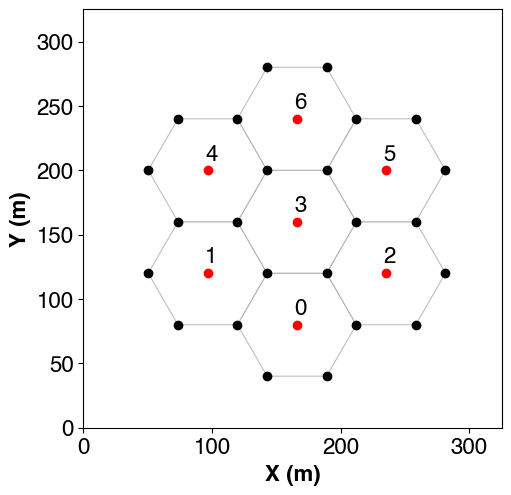

In [11]:
plotter_wf = NestedGridPlotter(fig_params={"figsize": (5, 5)})

for i, j in inj_grid_coordinates:
    plotter_wf.ax_dict["ax1-1"].plot(i, j, "ko")

for i, j in prod_grid_coordinates:
    plotter_wf.ax_dict["ax1-1"].plot(i, j, "ro")

patches = []
for polygon in polygons:
    # Add the polygon to the collection of patches
    xy = np.array(polygon)
    patches.append(Polygon(xy, closed=True, facecolor=None))
    # Plot the number of the polygon
p = PatchCollection(patches, alpha=0.75)
p.set_facecolors("white")
p.set_edgecolors("darkgrey")
p.set_linewidth(0.8)
p.set_linestyle("-")
plotter_wf.ax_dict["ax1-1"].add_collection(p)

for i, prod_coords in enumerate(prod_grid_coordinates):
    plotter_wf.ax_dict["ax1-1"].text(prod_coords[0] - 2, prod_coords[1] + 8, i)

plotter_wf.ax_dict["ax1-1"].set_aspect("equal", adjustable="box")
plotter_wf.ax_dict["ax1-1"].set_xlim(0, nx * dx)
plotter_wf.ax_dict["ax1-1"].set_ylim(0, ny * dy)
plotter_wf.ax_dict["ax1-1"].set_xlabel("X [m]", fontweight="bold")
plotter_wf.ax_dict["ax1-1"].set_ylabel("Y [m]", fontweight="bold")

fname = "7_cells_wellfield"
for format in ["png", "pdf"]:
    plotter_wf.fig.savefig(
        str(fig_save_path.joinpath(f"{fname}.{format}")), format=format
    )

In [12]:
prod_grid_coordinates[0]

(165.85680518387326, 80.0480947161671)

- Make some selection

In [13]:
mpl_polygons = []
shapely_polygons = []

# Iterate the polygons to create matplotlib and shapely polygon instances
for polygon in polygons:
    # Add the polygon to the collection of patches
    xy = np.array(polygon)
    mpl_polygons.append(Polygon(xy, closed=True, facecolor=None))
    shapely_polygons.append(ShapelyPolygon(xy))

# Generate well field polygons
full_box = ShapelyBox(0.0, 0.0, nx * dx, ny * dy)  # polygon covering all the grid
inner_area = cascaded_union(shapely_polygons)  # polygon covering the well-field area
buffered_inner_area = inner_area.buffer(10.0)  # add a 10 m buffer around the
buffered_external_area = full_box.difference(
    buffered_inner_area
)  # ouside well-field area

- Create the flowrates for the wells: 12 m3/h decreasing following an exponential... for the producers with a balanced injection (2 m3/h per associated cell for the injectors).

In [14]:
def gen_flowrates(amplitude: float, coef: float, nt: int, dt: float) -> NDArrayFloat:
    """Generate flowrates with a given amplitude and decrease coefficient.

    Parameters
    ----------
    amplitude : float
        Amplitude in m3/h.
    coef : float
        Decrease coefficient.
    nt : int
        Number of timesteps
    dt : float
        Timesteps.

    Returns
    -------
    np.ndarray
        The flowrates.
    """
    return amplitude * np.exp(coef * np.arange(nt) * dt)

- Generate a flowrates with an initial amplitude at 1 m3/h and plot it
- For now steady state

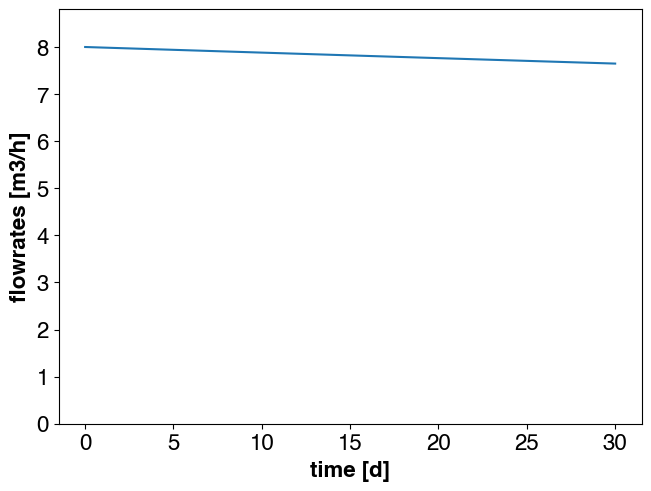

In [15]:
init_prod_flowrates = 8.0  # m3/s
flowrates = init_prod_flowrates * gen_flowrates(
    1.0, -0.0015, duration_in_days + 1, dt=1.0
)  # m3/h
time_in_days = np.arange(duration_in_days + 1)
# plt.plot(np.arange(nt + 1) * dt / 3600 / 24, flowrates)
# plt.ylim(0.0, init_prod_flowrates * 1.1)

plt.plot(np.arange(duration_in_days + 1), flowrates)
plt.ylim(0.0, init_prod_flowrates * 1.1)
if language == Lg.FRENCH:
    plt.ylabel("flowrates [m3/h]", fontweight="bold")
    plt.xlabel("time [d]", fontweight="bold")
else:
    plt.ylabel("débit [m3/h]", fontweight="bold")
    plt.xlabel("temps [j]", fontweight="bold")

fname = "flowrates_decrease"
for format in ["png", "pdf"]:
    plt.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

### Mineral grade: reference vs estimated

The mineral grades are defined in [mol/kg]. We calculate the conversion factor to obtain ppm and perform easier mass balances.

ConvU: parameter for converting the mineral content in [mol/kg] to metal grade in [ppm]. Note that the ConvU parameter is specific to the Uranium carrier phase: here Uraninite.

$C_{Uraninite}[\frac{mol}{kg}] = convU \times T_{Uranium}[ppm]$


and


$conv_u = \frac{1.023 \times density_{rock}}{238*porosity_{rock} \times 1000}$

Note the 1.023 is the conversion factor from molar mass to molal mass in CHESS.

In [16]:
rock_density = 1.63
conv_u_grade: NDArrayFloat = np.array(
    [1.023 * rock_density / (238.0 * porosity * 1000)]
)

- Conversion factor for uranium from mol/l to mg/l

In [17]:
conv_u_conc: float = (270.03 - 0.0016 * 2) * 1e3

- Functions to perform the conversions

In [18]:
def grade_ppm_to_mol_per_kg(x: Union[NDArrayFloat, float]) -> NDArrayFloat:
    return x * conv_u_grade


def grade_mol_per_kg_to_ppm(x: Union[NDArrayFloat, float]) -> NDArrayFloat:
    return x / conv_u_grade


def grade_mol_per_kg_to_ppm_1st_derivative(
    x: Union[NDArrayFloat, float]
) -> NDArrayFloat:
    return 1 / conv_u_grade


def conc_molpl_to_mgpl(x: Union[NDArrayFloat, float]) -> NDArrayFloat:
    return np.array(x * conv_u_conc)

- Using the SPDE approach, generate a random field

In [19]:
len_scale = 20.0  # m
kappa = 1 / len_scale
alpha = 1.0

mean = 300.0  # trend of the field
std = 150.0  # standard deviation of the field

# Create a precison matrix
Q_ref = spde.get_precision_matrix(
    nx, ny, nz, dx, dy, dz, kappa, alpha, spatial_dim=2, sigma=std
)
cholQ_ref = cholesky(Q_ref)
# Non conditonal simulation -> change the random state to obtain a different field
simu_ = spde.simu_nc(cholQ_ref, random_state=2026).reshape(ny, nx).T
reference_grade = np.abs(simu_ + mean)

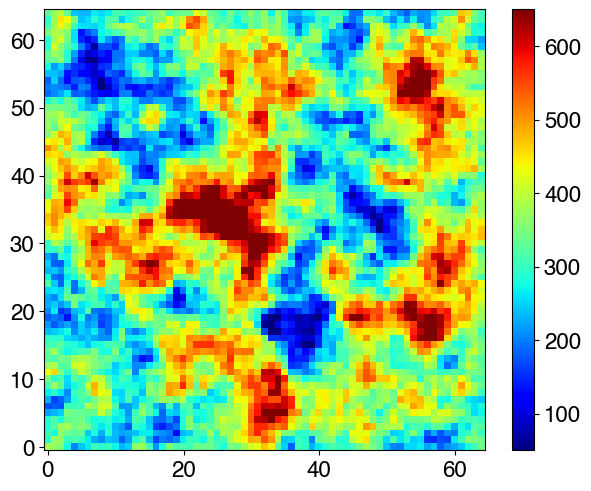

In [20]:
plt.imshow(
    reference_grade.T,
    origin="lower",
    cmap=plt.get_cmap("jet"),
    aspect="equal",
    vmin=50.0,
    vmax=650,
)
plt.colorbar()

- Simulation du krr

In [21]:
len_scale_krr = 20.0  # m
kappa_krr = 1 / len_scale
alpha_krr = 2.0

mean_krr = 1.3  # trend of the field
std_krr = 0.5  # standard deviation of the field

# Create a precison matrix
Q_krr = spde.get_precision_matrix(
    nx, ny, nz, dx, dy, dz, kappa_krr, alpha_krr, spatial_dim=2, sigma=std_krr
)
cholQ_krr = cholesky(Q_krr)
# Non conditonal simulation -> change the random state to obtain a different field
simu_krr = spde.simu_nc(cholQ_krr, random_state=2026).reshape(ny, nx).T
krr = np.abs(simu_krr + mean_krr)

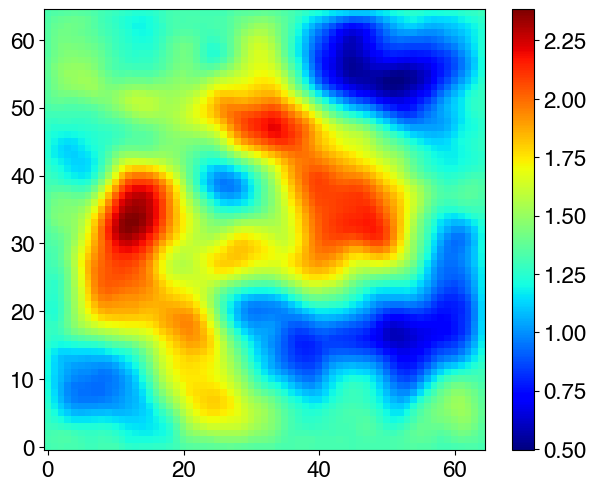

In [22]:
plt.imshow(
    krr.T,
    origin="lower",
    cmap=plt.get_cmap("jet"),
    aspect="equal",
)
plt.colorbar()

- Select some points from this field (drilling places) -> green dots on the map

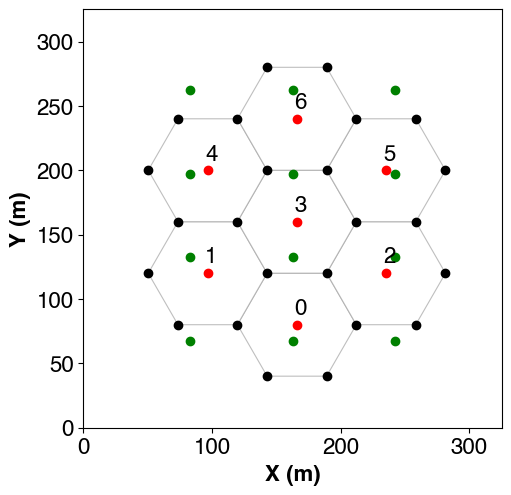

In [23]:
_ix = np.array([int(nx / 4), 2 * int(nx / 4), 3 * int(nx / 4)])
_iy = np.array([int(ny / 5), 2 * int(ny / 5), 3 * int(ny / 5), 4 * int(ny / 5)])

dat_coords = np.array(np.meshgrid(_ix, _iy)).reshape(2, -1)
# Get the node numbers
dat_nn = indices_to_node_number(dat_coords[0, :], nx, dat_coords[1, :])
dat_val = reference_grade.ravel("F")[dat_nn]

for i, j in dat_coords.T:
    plotter_wf.ax_dict["ax1-1"].plot((i + 0.5) * dx, (j + 0.5) * dy, "go")

plotter_wf.fig

- Generate 3 conditional simulations with more or less error on the known data with a varigram which is not exactly correct + one constant field (witness case)

In [24]:
# Generate new points with error -> systematic bias 200 ppm + some variance on the mesures
measure_era = dat_val / krr.ravel("F")[dat_nn]
measure_era_noisy = measure_era * (
    1 + np.random.default_rng(2025).normal(scale=0.1, size=dat_val.size)
)

# ) + 100 * np.random.default_rng(2025).normal(
#     scale=1.0, size=dat_val.size
# )) / 2
estimated_krr = 0.65
dat_val_wrong = measure_era_noisy * estimated_krr

# Condition with the exact data -> we assume a large noise over the data
dat_var_init = np.ones(dat_val.size) * (100**2)

# Compute the average on the data points (trend)
estimated_mean = np.average(dat_val_wrong)
estimated_std = float(np.std(dat_val_wrong))

alpha = 1

# Create a precison matrix
Q_init = spde.get_precision_matrix(
    nx, ny, 1, dx, dy, 1.0, kappa, alpha, spatial_dim=2, sigma=estimated_std
)
Q_init_c = spde.condition_precision_matrix(Q_init, dat_nn, dat_var_init)

# Decompose with cholesky
cholQ_init = cholesky(Q_init)
cholQ_init_c = cholesky(Q_init_c)

estimate_grade_simu = np.abs(
    spde.simu_c(
        cholQ_init,
        Q_init_c,
        cholQ_init_c,
        dat_val_wrong - estimated_mean,
        dat_nn,
        dat_var_init,
        random_state=2023,
    )
    .reshape(ny, nx)
    .T
    + estimated_mean
)

# estimate_grade_simu = np.abs(
#     spde.kriging(
#         Q_init_c,
#         dat_val_wrong - estimated_mean,
#         dat_nn,
#         cholQ_init_c,
#         dat_var_init,
#     )
#     .reshape(ny, nx)
#     .T
#     + estimated_mean
# )

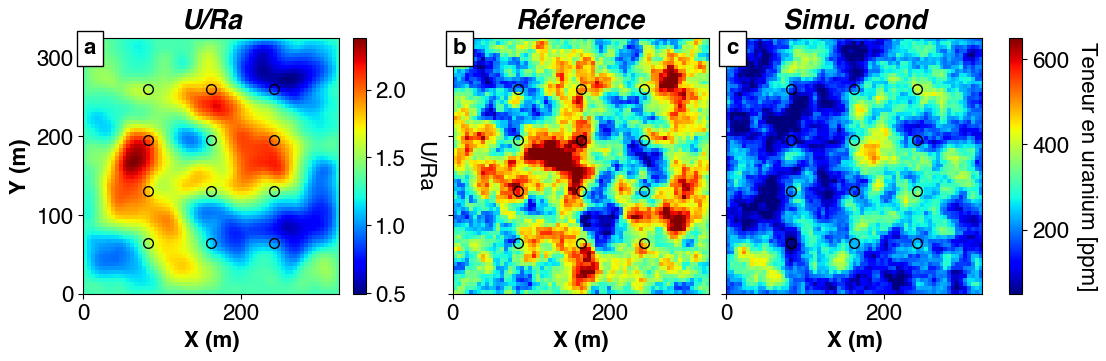

In [25]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (11, 3.5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1", "ax1-2", "ax1-3"]], sharey=True, sharex=True)
    },
)

# 1) Plot the grades
if language == Lg.ENGLISH:
    labels = ["Reference", "Simu. cond"]
    cbar_title = "Uranium grade [ppm]"
else:
    labels = ["Réference", "Simu. cond"]
    cbar_title = "Teneur en uranium [ppm]"

multi_imshow(
    axes=plotter.axes[1:],
    fig=plotter.fig,
    data={
        labels[0]: reference_grade,
        labels[1]: estimate_grade_simu,
    },
    cbar_title=cbar_title,
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "vmin": 50,
        "vmax": 650,
        "aspect": "equal",
    },
    xlabel="X [m]",
)

multi_imshow(
    axes=plotter.axes[:1],
    fig=plotter.fig,
    data={
        "U/Ra": krr,
    },
    cbar_title="U/Ra",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "aspect": "equal",
    },
    xlabel="X [m]",
    ylabel="Y [m]",
)

for ax in plotter.axes:
    # plot the sampling points here
    ax.plot(
        (dat_coords[0] + 0.5) * dx,
        (dat_coords[1] * dy),
        linestyle="None",
        marker="o",
        markersize=7,
        color="k",
        markerfacecolor="None",
    )

for letter, ax in zip(["a", "b", "c"], plotter.axes):
    ax.text(
        0.0,
        1.0,
        letter,
        color="k",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
    )

    # fontsize= 16
    # bbox = dict(facecolor='pink', alpha=0.2, edgecolor='red', boxstyle='square,pad=0.5')
    # ax.annotate(letter, xy=(0.0, 0.0),  xytext=(0,0.5*16), color='k', va="top", ha="left", fontweight="normal", textcoords="offset points",
    #         bbox=bbox)
fname = "u_grade_and_krr_ref_vs_priors"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

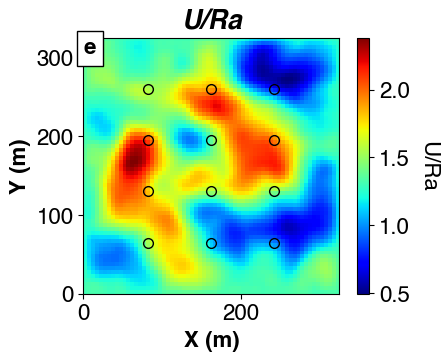

In [26]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (4.5, 3.5)},
    subplots_mosaic_params={"fig0": dict(mosaic=[["ax1-1"]], sharey=True, sharex=True)},
)

multi_imshow(
    axes=plotter.axes[:1],
    fig=plotter.fig,
    data={
        "U/Ra": krr,
    },
    cbar_title="U/Ra",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "aspect": "equal",
    },
    xlabel="X [m]",
    ylabel="Y [m]",
)

for ax in plotter.axes:
    # plot the sampling points here
    ax.plot(
        (dat_coords[0] + 0.5) * dx,
        (dat_coords[1] * dy),
        linestyle="None",
        marker="o",
        markersize=7,
        color="k",
        markerfacecolor="None",
    )

for letter, ax in zip(["e"], plotter.axes):
    ax.text(
        0.0,
        1.0,
        letter,
        color="k",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
    )

    # fontsize= 16
    # bbox = dict(facecolor='pink', alpha=0.2, edgecolor='red', boxstyle='square,pad=0.5')
    # ax.annotate(letter, xy=(0.0, 0.0),  xytext=(0,0.5*16), color='k', va="top", ha="left", fontweight="normal", textcoords="offset points",
    #         bbox=bbox)
fname = "krr"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Plot the reserves per mesh

In [27]:
def get_cell_reserves(
    u_field_grades: NDArrayFloat,
    cell_polygons: Sequence[Sequence[Tuple[float, float]]],
    nx: int,
    ny: int,
    dx: float,
    dy: float,
    dz: float,
) -> Sequence[float]:
    """Return the reserves in t under the given technological cell.

    Parameters
    ----------
    u_field_grades : NDArrayFloat
        Uraninite grades field in ppm. 2D Array.
    dx : float
        X dimension of one mesh [m].
    dy : float
        Y dimension of one mesh [m].
    dz : float
        Z dimension of one mesh [m].
    mask: NDArrayFloat
        Mask to apply before doing the selection.
    Returns
    -------
    float
        The associated uranium reserves in t.
    """
    # flatten points coordinates
    _x, _y, _z = node_number_to_indices(np.arange(nx * ny), nx, ny)
    _x = _x * dx + dx / 2
    _y = _y * dy + dy / 2
    grid_coords = np.array((_x, _y)).T

    cell_volume = dx * dy * dz  # m3
    # Conversion factor to go from a number of ppm per unit of volume to a mass in t (all cells are the same)
    conv_factor = cell_volume * rock_density * 1e-6

    reserves_list = []

    mask_sum = None
    for cell_polygon in cell_polygons:
        # Select the mesh that belongs to the polygon
        path = mpl.path.Path(cell_polygon)
        mask = path.contains_points(grid_coords)
        if mask_sum is not None:
            mask = np.logical_and(mask, ~mask_sum)
            mask_sum = np.logical_or(mask, mask_sum)
        else:
            mask_sum = mask
        reserves_list.append(float(u_field_grades[mask].sum() * conv_factor))
    return reserves_list

- Compute the reserve associated to the cells in t
- Need to transpose for the display

In [28]:
reference_reserves = get_cell_reserves(
    reference_grade.T.ravel(), polygons, nx, ny, dx, dy, dz
)
estimated_reserves_simu = get_cell_reserves(
    estimate_grade_simu.T.ravel(), polygons, nx, ny, dx, dy, dz
)

- Compute deviations

In [29]:
initial_u_dev_simu = np.sum(estimated_reserves_simu) - np.sum(reference_reserves)
initial_u_dev_simu_frac = initial_u_dev_simu / np.sum(reference_reserves)

logging.info(
    f"initial_U_dev_simu = {initial_u_dev_simu:.2f} t ({initial_u_dev_simu_frac * 100:.2f}%)"
)

INFO:root:initial_U_dev_simu = -9.88 t (-41.05%)


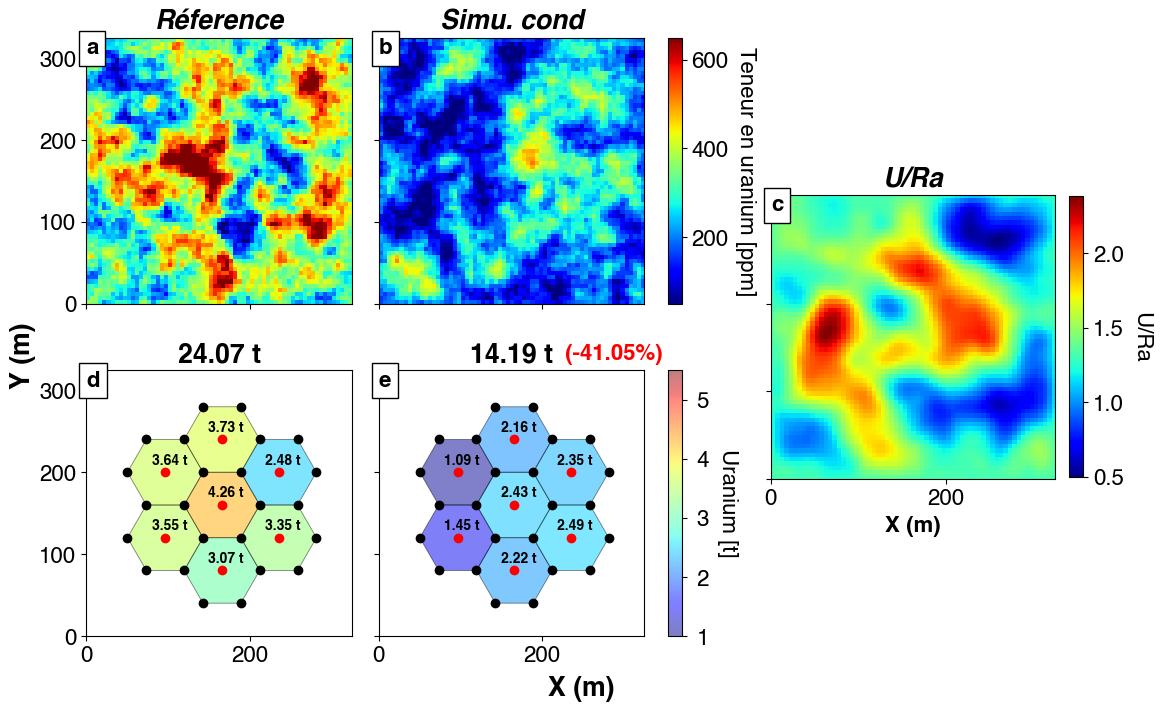

In [30]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (11.5, 7)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1", "ax2-1", "ax3-1"], ["ax1-2", "ax2-2", "ax3-1"]],
            sharey=True,
            sharex=True,
        ),
    },
)

# 1) Plot the grades
if language == Lg.ENGLISH:
    labels = ["Reference", "Simu. cond"]
    cbar_title = "Uranium grade [ppm]"
else:
    labels = ["Réference", "Simu. cond"]
    cbar_title = "Teneur en uranium [ppm]"

cbar_up = multi_imshow(
    axes=plotter.axes[:2],
    fig=plotter.fig,
    data={
        labels[0]: reference_grade,
        labels[1]: estimate_grade_simu,
    },
    cbar_title=cbar_title,
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "vmin": 50,
        "vmax": 650,
        "aspect": "equal",
    },
    cbar_kwargs={"pad": 0.01},
)

# 2) Plot the reserves
for _n, (ax, reserves) in enumerate(
    zip(
        [plotter.axes[3], plotter.axes[-1]],
        (
            reference_reserves,
            estimated_reserves_simu,
        ),
    )
):
    for i, j in inj_grid_coordinates:
        ax.plot(i, j, "ko")

    for i, j in prod_grid_coordinates:
        ax.plot(i, j, "ro")

    patches = []
    for i, cell_polygon in enumerate(polygons):
        # Add the polygon to the collection of patches
        xy = np.array(cell_polygon)
        patches.append(Polygon(xy, closed=True, facecolor=None))

        centroid = (xy.mean(axis=0)[0] - 10, xy.mean(axis=0)[1] + 10)

        ax.text(*centroid, f"{reserves[i]:.2f} t", fontsize=10, fontweight="bold")

        # Plot the number of the polygon
    p = PatchCollection(patches, alpha=0.5, cmap=plt.get_cmap("jet"))
    # p.set_facecolors("white")
    p.set_edgecolors("black")
    p.set_linewidth(0.6)
    p.set_linestyle("-")
    p.set_array(np.array(reserves, dtype=float))
    p.set_clim(1, 5.5)
    ax.add_collection(p)

    # Add the tonnages
    tmp = ax.set_title(f"{np.sum(reserves):.2f} t", fontweight="bold")

    if _n != 0:
        # Absolute deviation
        ton_diff_abs = np.sum(reserves) - np.sum(reference_reserves)
        # Relative deviation
        ton_diff_rel = ton_diff_abs / np.sum(reference_reserves)

        pos = tmp.get_position()
        txt = ax.text(
            pos[0] + 0.2,
            pos[1] + 0.04,
            f"({ton_diff_rel * 100:+.2f}%)",
            fontweight="bold",
            transform=ax.transAxes,
            color="r" if np.abs(ton_diff_rel) > 0.1 else "g",
        )
        # txt.set_bbox(tmp.get_bbox_patch().get_boxstyle())

# Add a common colorbar
cbar = plotter.fig.colorbar(
    p,
    ax=[plotter.axes[3], plotter.axes[-1]],
    orientation="vertical",
    fraction=0.1,
    format="%2.f",
    pad=0.01,
)
cbar.ax.get_yaxis().labelpad = 20
cbar.ax.set_ylabel("Uranium [t]", rotation=270)

# 3) Plot the U/Ra
cbar = multi_imshow(
    axes=plotter.axes[2:3],
    fig=plotter.fig,
    data={
        "U/Ra": krr,
    },
    cbar_title="U/Ra",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "aspect": "equal",
    },
    cbar_kwargs={"shrink": 0.47},
    xlabel="X [m]",
    # ylabel="Y [m]",
)

# Box dimensions
for ax in plotter.ax_dict.values():
    ax.set_xlim(0, nx * dx)
    ax.set_ylim(0, ny * dy)
    ax.set_aspect("equal", adjustable="box")

# plotter.fig.suptitle("Grades and tonnages", fontweight="bold", fontsize=22)
plotter.fig.supxlabel("X [m]", fontweight="bold")
plotter.fig.supylabel("Y [m]", fontweight="bold")

for letter, ax in zip(["a", "b", "c", "d", "e"], plotter.axes):
    ax.text(
        0.0,
        1.0,
        letter,
        color="k",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
    )

fname = "reserves_+_grades_per_cells_+_URa"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

In [31]:
# TODO: this is another version that I should move somewhere.

# plotter = NestedGridPlotter(
#     fig_params={"constrained_layout": True, "figsize": (13, 7)},
#     subfigs_params={
#         "ncols": 2, "wspace": 0.01, "width_ratios": [2, 1.05]
#     },
#     subplots_mosaic_params={
#         "left_col": dict(
#             mosaic=[["ax1-1", "ax2-1"], ["ax1-2", "ax2-2"]],
#             sharey=True,
#             sharex=True,
#         ),
#         "right_col": dict(
#             mosaic=[["ax1-3"]],
#         ),
#     },
# )

# # 1) Plot the grades
# if language == Lg.ENGLISH:
#     labels = ["Reference", "Simu. cond"]
#     cbar_title = "Uranium grade [ppm]"
# else:
#     labels = ["Réference", "Simu. cond"]
#     cbar_title = "Teneur en uranium [ppm]"

# cbar_up = multi_imshow(
#     axes=list(plotter.grouped_ax_dict["left_col"].values())[:2],
#     fig=plotter.subfigs["left_col"],
#     data={
#         labels[0]: reference_grade,
#         labels[1]: estimate_grade_simu,
#     },
#     cbar_title=cbar_title,
#     imshow_kwargs={
#         "cmap": plt.get_cmap("jet"),
#         "extent": [0.0, nx * dx, 0.0, ny * dy],
#         "vmin": 50,
#         "vmax": 650,
#         "aspect": "equal"
#     },
# )

# for ax in list(plotter.grouped_ax_dict["left_col"].values())[:2]:
#     # plot the sampling points here
#     ax.plot(
#         (dat_coords[0] + 0.5) * dx,
#         (dat_coords[1] * dy),
#         linestyle="None",
#         marker="o",
#         markersize=7,
#         color="k",
#         markerfacecolor="None",
#     )

# # 2) Plot the reserves
# for _n, (ax, reserves) in enumerate(
#     zip(
#         list(plotter.grouped_ax_dict["left_col"].values())[2:],
#         (
#             reference_reserves,
#             estimated_reserves_simu,
#         ),
#     )
# ):
#     for i, j in inj_grid_coordinates:
#         ax.plot(i, j, "ko")

#     for i, j in prod_grid_coordinates:
#         ax.plot(i, j, "ro")

#     patches = []
#     for i, cell_polygon in enumerate(polygons):
#         # Add the polygon to the collection of patches
#         xy = np.array(cell_polygon)
#         patches.append(Polygon(xy, closed=True, facecolor=None))

#         centroid = (xy.mean(axis=0)[0] - 10, xy.mean(axis=0)[1] + 10)

#         ax.text(*centroid, f"{reserves[i]:.2f} t", fontsize=10, fontweight="bold")

#         # Plot the number of the polygon
#     p = PatchCollection(patches, alpha=0.5, cmap=plt.get_cmap("jet"))
#     # p.set_facecolors("white")
#     p.set_edgecolors("black")
#     p.set_linewidth(0.6)
#     p.set_linestyle("-")
#     p.set_array(np.array(reserves, dtype=float))
#     p.set_clim(1, 5.5)
#     ax.add_collection(p)

#     # Add the tonnages
#     tmp = ax.set_title(f"{np.sum(reserves):.2f} t", fontweight="bold")

#     if _n != 0:
#         # Absolute deviation
#         ton_diff_abs = np.sum(reserves) - np.sum(reference_reserves)
#         # Relative deviation
#         ton_diff_rel = ton_diff_abs / np.sum(reference_reserves)

#         pos = tmp.get_position()
#         txt = ax.text(
#             pos[0] + 0.2,
#             pos[1] + 0.04,
#             f"({ton_diff_rel * 100:+.2f}%)",
#             fontweight="bold",
#             transform=ax.transAxes,
#             color="r" if np.abs(ton_diff_rel) > 0.1 else "g",
#         )
#         # txt.set_bbox(tmp.get_bbox_patch().get_boxstyle())

# # Box dimensions
# for ax in plotter.ax_dict.values():
#     ax.set_xlim(0, nx * dx)
#     ax.set_ylim(0, ny * dy)
#     ax.set_aspect("equal", adjustable="box")

# # Add a common colorbar
# cbar = plotter.subfigs["left_col"].colorbar(
#     p, ax=list(plotter.grouped_ax_dict["left_col"].values())[2:], orientation="vertical", fraction=0.1, format="%2.f"
# )
# cbar.ax.get_yaxis().labelpad = 20
# cbar.ax.set_ylabel("Uranium [t]", rotation=270)

# # Box dimensions
# for ax in plotter.ax_dict.values():
#     ax.set_xlim(0, nx * dx)
#     ax.set_ylim(0, ny * dy)
#     ax.set_aspect("equal", adjustable="box")


# # 3) Plot the U/Ra
# cbar = multi_imshow(
#     axes=[plotter.ax_dict["ax1-3"]],
#     fig=plotter.subfigs["right_col"],
#     data={
#         "U/Ra": krr,
#     },
#     cbar_title="U/Ra",
#     imshow_kwargs={
#         "cmap": plt.get_cmap("jet"),
#         "extent": [0.0, nx * dx, 0.0, ny * dy],
#         "aspect": "equal",
#     },
#     cbar_kwargs={"shrink": 0.425},
#     xlabel="X [m]",
#     # ylabel="Y [m]",
# )

# # plotter.fig.suptitle("Grades and tonnages", fontweight="bold", fontsize=22)
# plotter.fig.supxlabel("X [m]", fontweight="bold")
# plotter.fig.supylabel("Y [m]", fontweight="bold")

# for letter, ax in zip(["e", "a", "b", "c", "d"], plotter.axes):
#     ax.text(
#         0.0,
#         1.0,
#         letter,
#         color="k",
#         transform=ax.transAxes,
#         va="top",
#         ha="left",
#         fontweight="bold",
#         bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
#     )


# fname = "reserves_and_grades_per_cells"
# for format in ["png", "pdf"]:
#     plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

## Forward problem in demonstrator

In [32]:
time_params = dmfwd.TimeParameters(
    duration=duration_in_seconds,
    dt_init=dt_init,
    dt_min=dt_min,
    dt_max=dt_max,
    courant_factor=courant_factor,
)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dx)
geometry_fine = dmfwd.Geometry(nx=nx * 2, ny=ny * 2, dx=dx / 2, dy=dy / 2)
fl_params = dmfwd.FlowParameters(
    permeability=permeability,
    storage_coefficient=storage_coefficient,
    regime=dmfwd.FlowRegime.TRANSIENT,
    tolerance=1e-12,
)
tr_params = dmfwd.TransportParameters(
    diffusion=diffusion_coef,
    porosity=porosity,
    crank_nicolson_diffusion=1.0,
    crank_nicolson_advection=0.5,
    tolerance=1e-15,
)
gch_params = dmfwd.GeochemicalParameters(conc=c0, grade=M0, kv=kv, As=As, Ks=Ks)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params, tr_params, gch_params)
base_model_fine = dmfwd.ForwardModel(
    geometry_fine, time_params, fl_params, tr_params, gch_params
)

- Add source and sink terms

In [33]:
flw_times_in_s = np.arange(duration_in_days + 1) * 3600 * 24.0
prod_flw = -flowrates / 3600  # m3/h to m3/s
# times = np.arange(stop=nt + 1, start=0) * dt

for count_prod, (ix, iy) in enumerate(prod_grid_indices):
    name = f"producer_{ix}_{iy}"

    sink_term = dmfwd.SourceTerm(
        name,
        node_ids=np.array([indices_to_node_number(ix, nx, iy)]),
        times=flw_times_in_s,
        flowrates=prod_flw,
        concentrations=np.zeros(prod_flw.shape),
    )
    base_model.add_src_term(sink_term)

    sink_term_fine = dmfwd.SourceTerm(
        name,
        node_ids=np.array([indices_to_node_number(ix * 2, nx * 2, iy * 2)]),
        times=flw_times_in_s,
        flowrates=prod_flw,
        concentrations=np.zeros(prod_flw.shape),
    )
    base_model_fine.add_src_term(sink_term_fine)

for count_inj, (ix, iy) in enumerate(inj_grid_indices):
    x, y = inj_grid_coordinates[count_inj]
    name = f"injector_{ix}_{iy}"

    nb_prod_well_linked = 0
    # Find the number of producers that the injector is linked with
    for xp, yp in prod_grid_coordinates:
        # we take 20% margin on the cell radius
        if np.sqrt((x - xp) ** 2 + (y - yp) ** 2) < cell_radius * 1.2:
            nb_prod_well_linked += 1

    source_term = dmfwd.SourceTerm(
        name,
        node_ids=np.array([indices_to_node_number(ix, nx, iy)]),
        times=flw_times_in_s,
        flowrates=-prod_flw
        / 6.0
        * nb_prod_well_linked,  # /6.0 because of hexagonal cells
        concentrations=np.ones(prod_flw.shape) * c_inj,  # injection concentration
    )
    base_model.add_src_term(source_term)

    source_term_fine = dmfwd.SourceTerm(
        name,
        node_ids=np.array([indices_to_node_number(ix * 2, nx * 2, iy * 2)]),
        times=flw_times_in_s,
        flowrates=-prod_flw
        / 6.0
        * nb_prod_well_linked,  # /6.0 because of hexagonal cells
        concentrations=np.ones(prod_flw.shape) * c_inj,  # injection concentration
    )
    base_model_fine.add_src_term(source_term_fine)

- Check the hydraulic balance

In [34]:
total_prod_flow = 0
total_inj_flow = 0

for source_term in base_model.source_terms:
    _dt = np.diff(flw_times_in_s)  # timesteps in s
    total_inj_flow += np.sum(
        np.where(source_term.flowrates > 0, source_term.flowrates, 0.0)[1:] * _dt
    )
    total_prod_flow += np.sum(
        np.where(source_term.flowrates < 0, -source_term.flowrates, 0.0)[1:] * _dt
    )

print(f"total_prod_flow = {total_prod_flow} m3")
print(f"total_inj_flow = {total_inj_flow} m3")

total_prod_flow_fine = 0
total_inj_flow_fine = 0
for source_term in base_model_fine.source_terms:
    _dt = np.diff(flw_times_in_s)  # timesteps in s
    total_inj_flow_fine += np.sum(
        np.where(source_term.flowrates > 0, source_term.flowrates, 0.0)[1:] * _dt
    )
    total_prod_flow_fine += np.sum(
        np.where(source_term.flowrates < 0, -source_term.flowrates, 0.0)[1:] * _dt
    )

print(f"total_prod_flow_fine = {total_prod_flow_fine} m3")
print(f"total_inj_flow_fine = {total_inj_flow_fine} m3")

# This test should fail if there is any issue !
assert np.round(total_prod_flow, 4) == np.round(total_inj_flow, 4)

total_prod_flow = 39396.6939777571 m3
total_inj_flow = 39396.69397775711 m3
total_prod_flow_fine = 39396.6939777571 m3
total_inj_flow_fine = 39396.69397775711 m3


In [35]:
source_term.times.size

31

- Create two models

In [36]:
def coarse_field_to_fine(field: NDArrayFloat) -> NDArrayFloat:
    new_field = np.zeros((field.shape[0] * 2, field.shape[1] * 2))
    new_field[1::2, 1::2] = field
    new_field[1::2, ::2] = field
    new_field[::2, ::2] = field
    new_field[::2, 1::2] = field
    return new_field


def fine_to_coarse(field: NDArrayFloat) -> NDArrayFloat:
    tmp = np.atleast_2d(np.mean((field[::2, :], field[1::2, :]), axis=0))
    return np.mean((tmp[:, ::2], tmp[:, 1::2]), axis=0)

In [37]:
model_reference = copy.deepcopy(base_model_fine)
model_estimate = copy.deepcopy(base_model)

# Exact initial uranium grade
model_reference.tr_model.set_initial_grade(
    coarse_field_to_fine(grade_ppm_to_mol_per_kg(reference_grade))
)
# Estimated initial uranim grade
model_estimate.tr_model.set_initial_grade(grade_ppm_to_mol_per_kg(estimate_grade_simu))

- Run the models

In [38]:
solver_reference = dmfwd.ForwardSolver(model_reference)
solver_reference.solve(is_verbose=False)

In [39]:
solver_estimate_simu = dmfwd.ForwardSolver(model_estimate)
solver_estimate_simu.solve(is_verbose=False)

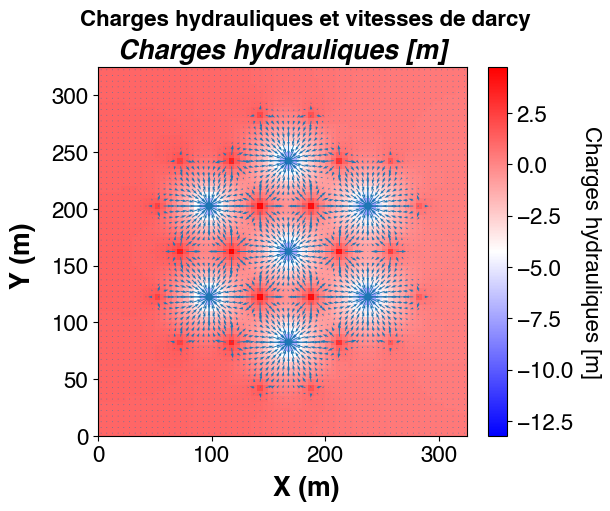

In [40]:
time_index_1 = 10
time_index_2 = 20

plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (6, 5)},
    # subfigs_params={"nrows": 1},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"]], sharey=True, sharex=True),
    },
)

if language == Lg.ENGLISH:
    label = "Hydraulic head [m]"
else:
    label = "Charges hydrauliques [m]"

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        label: model_estimate.fl_model.head[:, :, time_index_1],
        #         "Head [m] 2": model_estimate.fl_model.head[:, :, time_index_2],
    },
    cbar_title=label,
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "aspect": "equal"},
)

for ax, time_index in zip(plotter.axes, [time_index_1, time_index_2]):
    Y, X = np.meshgrid((np.arange(nx) + 0.5) * dx, (np.arange(ny) + 0.5) * dy)
    ax.quiver(
        X,
        Y,
        model_estimate.fl_model.u_darcy_x_center[:, :, time_index],
        model_estimate.fl_model.u_darcy_y_center[:, :, time_index],
        color="C0",
        scale_units="xy",
    )

# plotter.ax_dict["ax1-1"].set_title("Heads [m]", fontweight="bold", fontstyle="italic")
# plotter.ax_dict["ax1-2"].set_title("Darcy velocity [m/s]", fontweight="bold", fontstyle="italic")

if language == Lg.ENGLISH:
    title = "Hydraulic head and darcy velocities"
else:
    title = "Charges hydrauliques et vitesses de darcy"
plotter.subfigs["fig0"].suptitle(title, fontweight="bold", fontsize=16)
plotter.subfigs["fig0"].supxlabel("X [m]", fontweight="bold")
plotter.subfigs["fig0"].supylabel("Y [m]", fontweight="bold")

fname = "heads_and_velocities"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Plot the concentration evolution

## Observations and associated uncertainties

- We select only 10% of the data points available to get something more realistic

In [41]:
freq_measure_in_days = 2  # one measure every two days
n_sampled_days = duration_in_days_inv / freq_measure_in_days

obs_times_in_s = np.arange(n_sampled_days) * 3600 * 24 * freq_measure_in_days
obs_times_in_d = obs_times_in_s / 3600 / 24
obs_times_in_s

array([      0.,  172800.,  345600.,  518400.,  691200.,  864000.,
       1036800., 1209600., 1382400., 1555200., 1728000., 1900800.,
       2073600., 2246400., 2419200.])

- Create a function to add some noise to the observations

In [42]:
noise_std: float = 2e-5  # This is an absolute value


def get_white_noise(shape: Iterable[int]) -> NDArrayFloat:
    """
    Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    mean_noise = 0.0  # mean
    return np.random.default_rng(2021).normal(
        mean_noise, noise_std, size=np.array(shape)
    )


# Generate a white noise
obs_noise: NDArrayFloat = get_white_noise((len(prod_grid_indices), obs_times_in_s.size))

- Noise in mg/l

In [43]:
conc_molpl_to_mgpl(noise_std)

array(5.400536)

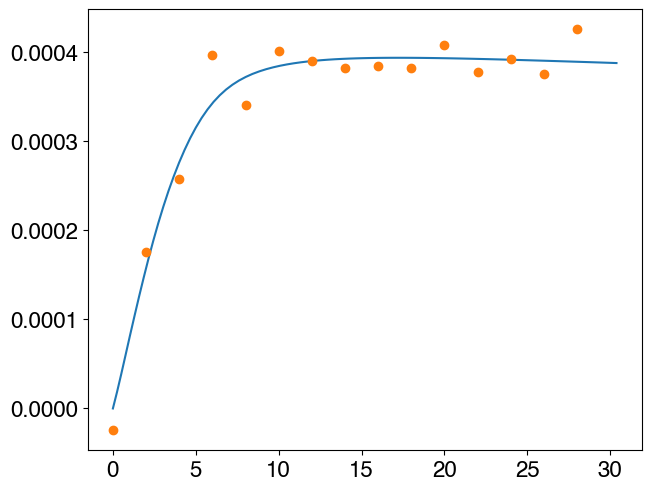

In [44]:
simu_times_ref_in_s = model_reference.time_params.times
simu_times_ref_in_d = simu_times_ref_in_s / 3600 / 24

simu_times_est_in_s = model_estimate.time_params.times
simu_times_est_in_d = simu_times_est_in_s / 3600 / 24

obs_values = np.zeros((len(prod_grid_indices), obs_times_in_s.size))

for count, (ix, iy) in enumerate(prod_grid_indices_fine):
    # interpolate the values
    obs_values[count] = (
        interp1d(
            simu_times_ref_in_s, model_reference.tr_model.conc[ix, iy, :], kind="cubic"
        )(obs_times_in_s)
        + obs_noise[count, :]
    )

count = 2

ix, iy = prod_grid_indices_fine[count]
plt.plot(simu_times_ref_in_d, model_reference.tr_model.conc[ix, iy, :])
plt.plot(
    obs_times_in_d,
    obs_values[count],
    marker="o",
    linestyle="none",
)

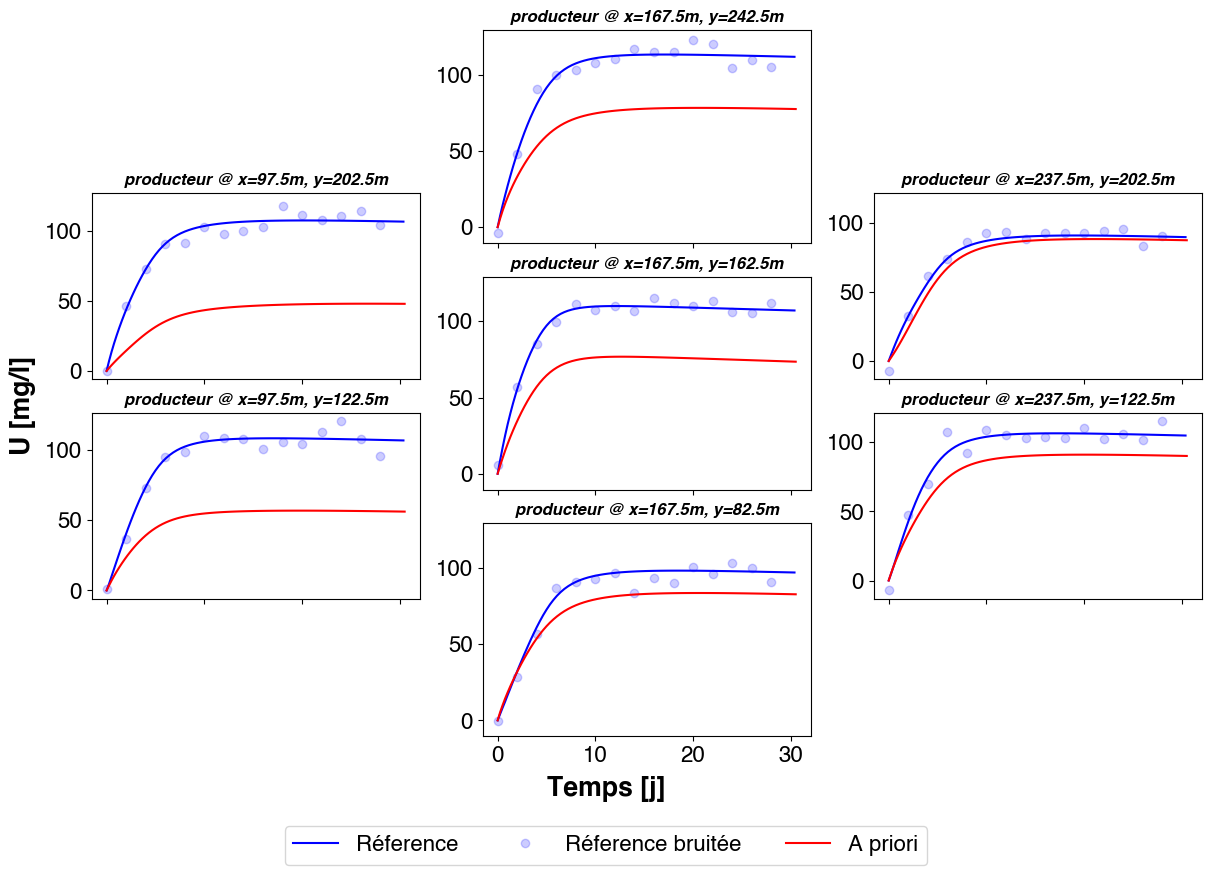

In [45]:
# Indicate the order in which to plot
obs_plot_locations = ["ax2-3", "ax1-2", "ax3-2", "ax2-2", "ax1-1", "ax3-1", "ax2-1"]

plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (12, 8)},
    subfigs_params={
        "ncols": 3  # np.unique(np.array(prod_grid_locations)[:, 0].round()).size,
    },
    subplots_mosaic_params={
        "left_col": dict(
            mosaic=[["ghost1"], ["ax1-1"], ["ax1-2"], ["ghost2"]],
            gridspec_kw=dict(
                height_ratios=[1.0, 1.2, 1.2, 1.0],
            ),
            sharey=True,
            sharex=True,
        ),
        "centered_col": dict(
            mosaic=[["ax2-1"], ["ax2-2"], ["ax2-3"]], sharey=True, sharex=True
        ),
        "right_col": dict(
            mosaic=[["ghost3"], ["ax3-1"], ["ax3-2"], ["ghost4"]],
            gridspec_kw=dict(
                height_ratios=[1.0, 1.2, 1.2, 1.0],
            ),
            sharey=True,
            sharex=True,
        ),
    },
)

# hide axes and borders
plotter.ax_dict["ghost1"].axis("off")
plotter.ax_dict["ghost2"].axis("off")
plotter.ax_dict["ghost3"].axis("off")
plotter.ax_dict["ghost4"].axis("off")

# Static plot
for count, ((ix, iy), ax_name) in enumerate(zip(prod_grid_indices, obs_plot_locations)):
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy

    if language == Lg.ENGLISH:
        obs_well_name = f"obs. well @ x={x:.1f}m, y={y:.1f}m"
    else:
        obs_well_name = f"producteur @ x={x:.1f}m, y={y:.1f}m"

    ax = plotter.ax_dict[ax_name]
    ax.set_title(obs_well_name, fontweight="bold", fontsize=12, fontstyle="italic")

    if language == Lg.ENGLISH:
        labels = ["Reference", "Reference noisy", "A priori"]
    else:
        labels = ["Réference", "Réference bruitée", "A priori"]

    data = {
        labels[0]: {
            "x": simu_times_ref_in_d,
            "y": conc_molpl_to_mgpl(model_reference.tr_model.conc[ix * 2, iy * 2, :]),
            "kwargs": {"c": "b", "linestyle": "-"},
        },
        labels[1]: {
            "x": obs_times_in_d,
            "y": conc_molpl_to_mgpl(obs_values[count]),
            "kwargs": {"c": "b", "marker": "o", "linestyle": "None", "alpha": 0.2},
        },
        labels[2]: {
            "x": simu_times_est_in_d,
            "y": conc_molpl_to_mgpl(model_estimate.tr_model.conc[ix, iy, :]),
            "kwargs": {"c": "r", "linestyle": "-"},
        },
    }

    for k, v in data.items():
        ax.plot(v["x"], v["y"], **v["kwargs"], label=k)

    # ax.set_xlabel("Time", fontweight="bold")
    # ax.set_xlabel("T_Cinet [mol/s]", fontweight="bold")

plotter.add_fig_legend(ncol=3)

if language == Lg.ENGLISH:
    plotter.fig.supxlabel("Time [d]", fontweight="bold")
    plotter.fig.supylabel("U [mg/l]", fontweight="bold")
else:
    plotter.fig.supxlabel("Temps [j]", fontweight="bold")
    plotter.fig.supylabel("U [mg/l]", fontweight="bold")

fname = "U_at_producers_before_inv"
for format in ["png", "pdf"]:
    plotter.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Define a function to plot the results afterwards

In [46]:
def plot_inv_res_conc_at_producers(
    *,
    ref_model: dmfwd.ForwardModel,
    prior_model: dmfwd.ForwardModel,
    inversed_model: dmfwd.ForwardModel,
    case_name: str,
) -> NestedGridPlotter:
    """

    Parameters
    ----------
    ref_model : _type_
        _description_
    prior_model : _type_
        _description_
    inversed_model : _type_
        _description_

    Returns
    -------
    NestedGridPlotter
        _description_
    """
    # Indicate the order in which to plot
    obs_plot_locations = ["ax2-3", "ax1-2", "ax3-2", "ax2-2", "ax1-1", "ax3-1", "ax2-1"]

    plotter = NestedGridPlotter(
        fig_params={"constrained_layout": True, "figsize": (12, 8)},
        subfigs_params={
            "ncols": 3  # np.unique(np.array(prod_grid_locations)[:, 0].round()).size,
        },
        subplots_mosaic_params={
            "left_col": dict(
                mosaic=[["ghost1"], ["ax1-1"], ["ax1-2"], ["ghost2"]],
                gridspec_kw=dict(
                    height_ratios=[1.0, 1.2, 1.2, 1.0],
                ),
                sharey=True,
                sharex=True,
            ),
            "centered_col": dict(
                mosaic=[["ax2-1"], ["ax2-2"], ["ax2-3"]], sharey=True, sharex=True
            ),
            "right_col": dict(
                mosaic=[["ghost3"], ["ax3-1"], ["ax3-2"], ["ghost4"]],
                gridspec_kw=dict(
                    height_ratios=[1.0, 1.2, 1.2, 1.0],
                ),
                sharey=True,
                sharex=True,
            ),
        },
    )

    # hide axes and borders
    plotter.ax_dict["ghost1"].axis("off")
    plotter.ax_dict["ghost2"].axis("off")
    plotter.ax_dict["ghost3"].axis("off")
    plotter.ax_dict["ghost4"].axis("off")

    # Static plot
    for count, ((ix, iy), ax_name) in enumerate(
        zip(prod_grid_indices, obs_plot_locations)
    ):
        x = (ix + 0.5) * dx
        y = (iy + 0.5) * dy

        if language == Lg.ENGLISH:
            obs_well_name = f"obs. well @ x={x:.1f}m, y={y:.1f}m"
        else:
            obs_well_name = f"producteur @ x={x:.1f}m, y={y:.1f}m"

        ax = plotter.ax_dict[ax_name]
        ax.set_title(obs_well_name, fontweight="bold", fontsize=12, fontstyle="italic")

        if language == Lg.ENGLISH:
            labels = [
                "Reference",
                "Reference noisy",
                "A priori",
                f"Post-inversion ({case_name})",
            ]
        else:
            labels = [
                "Réference",
                "Réference bruitée",
                "A priori",
                f"Post-inversion ({case_name})",
            ]

        data = {
            labels[0]: {
                "x": simu_times_ref_in_d,
                "y": conc_molpl_to_mgpl(ref_model.tr_model.conc[ix * 2, iy * 2, :]),
                "kwargs": {"c": "b", "linestyle": "-", "alpha": 0.25},
            },
            labels[1]: {
                "x": obs_times_in_d,
                "y": conc_molpl_to_mgpl(obs_values[count]),
                "kwargs": {"c": "b", "marker": "o", "linestyle": "None", "alpha": 0.2},
            },
            labels[2]: {
                "x": simu_times_est_in_d,
                "y": conc_molpl_to_mgpl(prior_model.tr_model.conc[ix, iy, :]),
                "kwargs": {"c": "r"},
            },
            labels[3]: {
                "x": simu_times_est_in_d,
                "y": conc_molpl_to_mgpl(inversed_model.tr_model.conc[ix, iy, :]),
                "kwargs": {"c": "g", "linestyle": "--"},
            },
        }

        for k, v in data.items():
            if v["x"].shape[0] != v["y"].shape[0]:
                print(k)
            ax.plot(v["x"], v["y"], **v["kwargs"], label=k)

        # ax.set_xlabel("Time", fontweight="bold")
        # ax.set_xlabel("T_Cinet [mol/s]", fontweight="bold")

        # Add the end of inversion
        # ax.axvline(x=time_all[obs_time_idx][-1], linestyle="--", color="k", label="fin d'inversion", alpha=0)

        if language == Lg.ENGLISH:
            ax.axvspan(
                0,
                obs_times_in_d[-1],
                color="grey",
                alpha=0.25,
                label="inversion period",
            )
        else:
            ax.axvspan(
                0,
                obs_times_in_d[-1],
                color="grey",
                alpha=0.25,
                label="Période inversion",
            )

    plotter.add_fig_legend(ncol=3)

    if language == Lg.ENGLISH:
        plotter.fig.supxlabel("Time [d]", fontweight="bold")
        plotter.fig.supylabel("U [mg/l]", fontweight="bold")
    else:
        plotter.fig.supxlabel("Temps [j]", fontweight="bold")
        plotter.fig.supylabel("U [mg/l]", fontweight="bold")

    fname = f"U_at_producers_post_inv_{case_name}"
    for format in ["png", "pdf"]:
        plotter.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)
    return plotter

In [47]:
def plot_inv_res_grade_and_reserves(
    *,
    ref_grade: NDArrayFloat,
    prior_grade: NDArrayFloat,
    inversed_grade: NDArrayFloat,
    case_name: str,
) -> NestedGridPlotter:
    plotter = NestedGridPlotter(
        fig_params={"constrained_layout": True, "figsize": (15, 7)},
        subplots_mosaic_params={
            "fig0": dict(
                mosaic=[
                    ["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
                    ["ax2-1", "ax2-2", "ax2-3", "ax2-4"],
                ],
                sharey=True,
                sharex=True,
            )
        },
    )

    data = {
        "Reference": ref_grade,
        "Cond sim dat": prior_grade,
        "Inversed": inversed_grade,
        "Residuals": np.abs(ref_grade - inversed_grade),
    }

    data_reserves = {}
    for k, v in data.items():
        data_reserves[k] = get_cell_reserves(v.T.ravel(), polygons, nx, ny, dx, dy, dz)

    # 1) Plot the grades
    cbar_up = multi_imshow(
        axes=plotter.axes[:4],
        fig=plotter.fig,
        data=data,
        cbar_title="Uranium grade [ppm]",
        imshow_kwargs={
            "cmap": plt.get_cmap("jet"),
            "extent": [0.0, nx * dx, 0.0, ny * dy],
            "vmin": 50,
            "vmax": 650,
        },
    )

    for ax in plotter.axes[:4]:
        # plot the sampling points here
        ax.plot(
            (dat_coords[0] + 0.5) * dx,
            (dat_coords[1] * dy),
            linestyle="None",
            marker="o",
            markersize=7,
            color="k",
            markerfacecolor="None",
        )

    # 2) Plot the reserves
    for _n, ax in enumerate(plotter.axes[4:]):
        reserves = list(data_reserves.values())[_n]

        for i, j in inj_grid_coordinates:
            ax.plot(i, j, "ko")

        for i, j in prod_grid_coordinates:
            ax.plot(i, j, "ro")

        patches = []
        for i, cell_polygon in enumerate(polygons):
            # Add the polygon to the collection of patches
            xy = np.array(cell_polygon)
            patches.append(Polygon(xy, closed=True, facecolor=None))

            centroid = (xy.mean(axis=0)[0] - 10, xy.mean(axis=0)[1] + 10)

            ax.text(*centroid, f"{reserves[i]:.2f} t", fontsize=10, fontweight="bold")

            # Plot the number of the polygon
        p = PatchCollection(patches, alpha=0.5, cmap=plt.get_cmap("jet"))
        # p.set_facecolors("white")
        p.set_edgecolors("black")
        p.set_linewidth(0.6)
        p.set_linestyle("-")
        p.set_array(np.array(reserves, dtype=float))
        p.set_clim(1, 5.5)
        ax.add_collection(p)

        # Add the tonnages
        tmp = ax.set_title(f"{np.sum(reserves):.2f} t", fontweight="bold")

        if _n != 0:
            # Absolute deviation
            ton_diff_abs = np.sum(reserves) - np.sum(reference_reserves)
            # Relative deviation
            ton_diff_rel = ton_diff_abs / np.sum(reference_reserves)

            pos = tmp.get_position()
            txt = ax.text(
                pos[0] + 0.2,
                pos[1] + 0.04,
                f"({ton_diff_rel * 100:+.2f}%)",
                fontweight="bold",
                transform=ax.transAxes,
                color="r" if np.abs(ton_diff_rel) > 0.1 else "g",
            )
            # txt.set_bbox(tmp.get_bbox_patch().get_boxstyle())

    # Box dimensions
    for ax in plotter.ax_dict.values():
        ax.set_xlim(0, nx * dx)
        ax.set_ylim(0, ny * dy)
        ax.set_aspect("equal", adjustable="box")

    # Add a common colorbar
    cbar = plotter.fig.colorbar(
        p, ax=plotter.axes[4:], orientation="vertical", fraction=0.1, format="%2.f"
    )
    cbar.ax.get_yaxis().labelpad = 20
    cbar.ax.set_ylabel("Uranium [t]", rotation=270)

    # Box dimensions
    for ax in plotter.ax_dict.values():
        ax.set_xlim(0, nx * dx)
        ax.set_ylim(0, ny * dy)
        ax.set_aspect("equal", adjustable="box")

    # plotter.fig.suptitle("Grades and tonnages", fontweight="bold", fontsize=22)
    plotter.fig.supxlabel("X [m]", fontweight="bold")
    plotter.fig.supylabel("Y [m]", fontweight="bold")

    fname = f"reserves_and_grades_per_cells_post_inv_{case_name}"
    for format in ["png", "pdf"]:
        plotter.fig.savefig(
            str(fig_save_path.joinpath(f"{fname}.{format}")), format=format
        )
    return plotter

## Inversion tests

- Define a threshold (minimum objective function)

In [48]:
threshold_loss = 5e-3  # we want to reduce the initial loss function a hundred times

In [49]:
is_run_adjoint = True

In [50]:
if is_run_all or is_run_adjoint:
    # Define a covariance matrix without any datapoints
    # cov_m = SparseInvCovarianceMatrix(Q_init)
    cov_m = SparseInvCovarianceMatrix(Q_init)  # We use the reference matrix

    # See if it is the same using the field in mol/kg -> need to rely on a preconditioner
    reg_adjoint = GeostatisticalRegularizator(
        cov_m=cov_m,
        prior=MeanPriorTerm(),
        is_preconditioned=False,
        transform=grade_mol_per_kg_to_ppm,
        transform_1st_derivative=grade_mol_per_kg_to_ppm_1st_derivative,
    )

    adjusted_param_adjoint = dminv.AdjustableParameter(
        name=dminv.ParameterName.INITIAL_GRADE,
        lbound=0.0,
        ubound=float(grade_ppm_to_mol_per_kg(700.0)),
        regularizators=[reg_adjoint],
        # span=(slice(4, -4), slice(4, -4)) # exclude the border
        filters=[GaussianFilter(sigmas=(2.0))],
    )

    from typing import Dict  # Just for linting

    observables = []
    for i, (ix, iy) in enumerate(prod_grid_indices):
        # Careful not to forget the x2

        observables.append(
            dminv.Observable(
                state_variable=dminv.StateVariable.CONCENTRATION,
                node_indices=indices_to_node_number(ix, nx, iy),
                times=obs_times_in_s,
                values=obs_values[i],
                uncertainties=noise_std,
            )
        )

    # Add well data

    # Create an executor to keep track of the adjoint model
    solver_config_adjoint = dminv.ScipySolverConfig(
        solver_name="L-BFGS-B",
        solver_options={
            "maxfun": 25,
            "maxiter": 25,
            "ftol": threshold_loss,
            "gtol": 1e-6,
        },
        is_check_gradient=False,
        max_optimization_round_nb=2,
        max_fun_first_round=5,
        max_fun_per_round=15,
    )
    model_adjusted_adjoint = copy.deepcopy(model_estimate)
    model_adjusted_adjoint.time_params.duration = duration_in_seconds_inv

    inverse_model_adjoint = dminv.InverseModel(adjusted_param_adjoint, observables)
    executor_adjoint = dminv.ScipyInversionExecutor(
        model_adjusted_adjoint, inverse_model_adjoint, solver_config_adjoint
    )

    # Compute a first objective function
    executor_adjoint.scaled_loss_function(
        get_param_values(adjusted_param_adjoint, is_preconditioned=True),
        is_save_state=False,
    )

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 18.957334796283007
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 1.0



In [51]:
if is_run_all or is_run_adjoint:
    res = executor_adjoint.run()

INFO:root:============================= Inversion Parameters =============================
INFO:root:Method                                            : L-BFGS-B
INFO:root:
INFO:root:Number of adjusted parameters                     : 1
INFO:root:Number of unknowns (adjusted values)              : 4225
INFO:root:Number of observables                             : 7
INFO:root:Number of observation data points (values)        : 105
INFO:root:================================================================================
INFO:root:Entering optimization loop: 1
INFO:root:- Running forward model # 1


5


INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 18.957334796283007
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 1.0

INFO:root:- Running gradient # 1
INFO:root:- Gradient eval # 1 over

INFO:root:- Running forward model # 2
INFO:root:- Run # 2 over
INFO:root:Loss (obs fit)        = 21.2503915116925
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 1.1209588130425958

INFO:root:- Running gradient # 2
INFO:root:- Gradient eval # 2 over

INFO:root:- Running forward model # 3
INFO:root:- Run # 3 over
INFO:root:Loss (obs fit)        = 2.7476044060926283
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 0.14493621786071717

INFO:root:- Running gradient # 3
INFO:root:- Gradient eval # 3 over

INFO:root:- Running forward model # 4
INFO:root:- Run # 4 

15


INFO:root:- Run # 7 over
INFO:root:Loss (obs fit)        = 0.5658796530513135
INFO:root:Loss (regularization) = 0.5658796530513135
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 0.05970033859002863

INFO:root:- Running gradient # 7
INFO:root:- Gradient eval # 7 over

INFO:root:- Running forward model # 8
INFO:root:- Run # 8 over
INFO:root:Loss (obs fit)        = 3.994532429061142
INFO:root:Loss (regularization) = 198.59481797296203
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 10.686594533412215

INFO:root:- Running gradient # 8
INFO:root:- Gradient eval # 8 over

INFO:root:- Running forward model # 9
INFO:root:- Run # 9 over
INFO:root:Loss (obs fit)        = 0.5275018052799579
INFO:root:Loss (regularization) = 0.29278670593860445
INFO:root:Scaling factor        = 0.052750031095936095
INFO:root:Loss (scaled)         = 0.04327024447441829

INFO:root:- Running gradient # 9
INFO:root:- Gradient eval # 9 o

In [52]:
if is_run_all or is_run_adjoint:
    logging.info(res)

INFO:root:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.03166048579453366
        x: [ 6.965e-03  5.886e-03 ...  6.508e-03  7.538e-03]
      nit: 3
      jac: [-5.291e-03 -1.463e-02 ... -8.963e-03 -4.088e-03]
     nfev: 5
     njev: 5
 hess_inv: <4225x4225 LbfgsInvHessProduct with dtype=float64>


- Run a full simulation with hm

In [53]:
model_adjusted_adjoint_full = copy.deepcopy(model_adjusted_adjoint)
model_adjusted_adjoint_full.time_params.duration = duration_in_seconds

solver_adjusted_adjoint = dmfwd.ForwardSolver(model_adjusted_adjoint_full)
solver_adjusted_adjoint.solve()

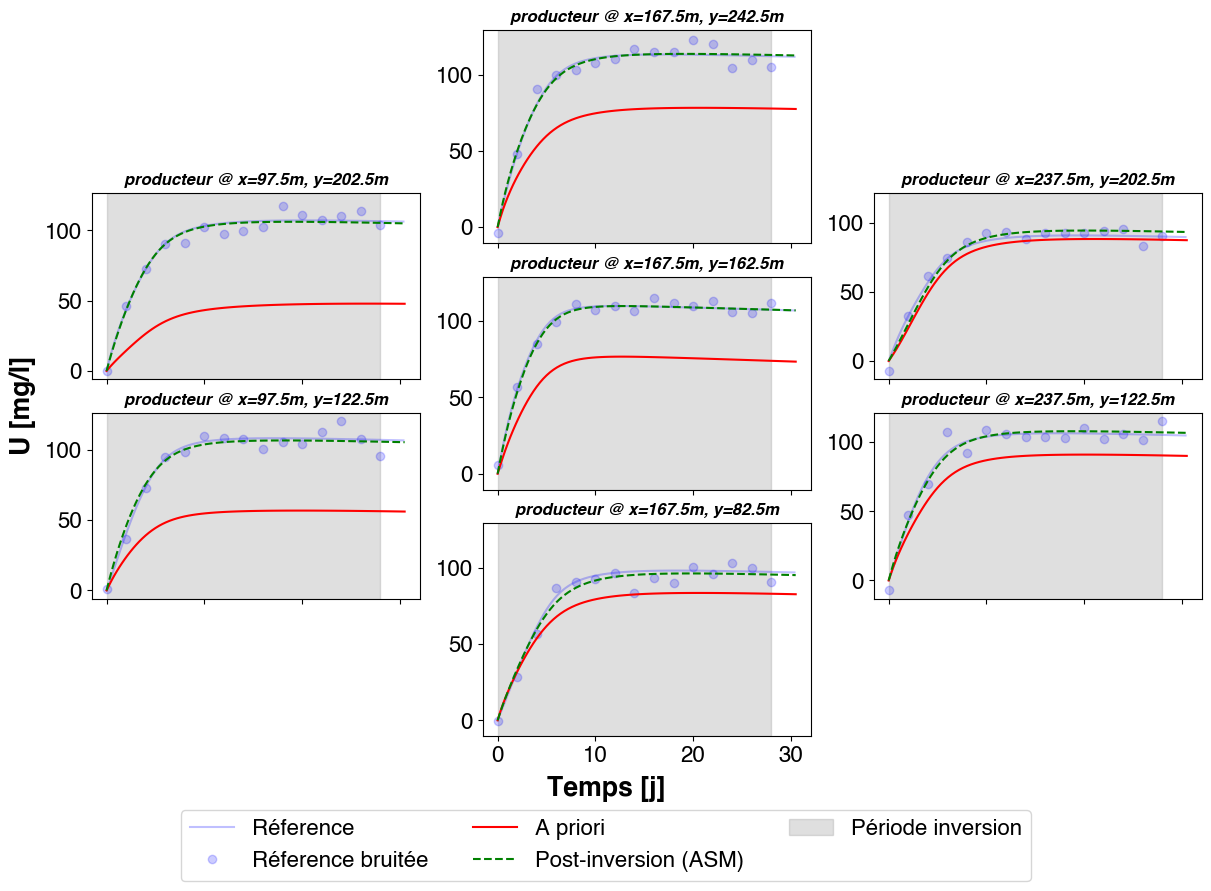

In [54]:
plot_inv_res_conc_at_producers(
    ref_model=model_reference,
    prior_model=model_estimate,
    inversed_model=model_adjusted_adjoint_full,
    case_name="ASM",
)

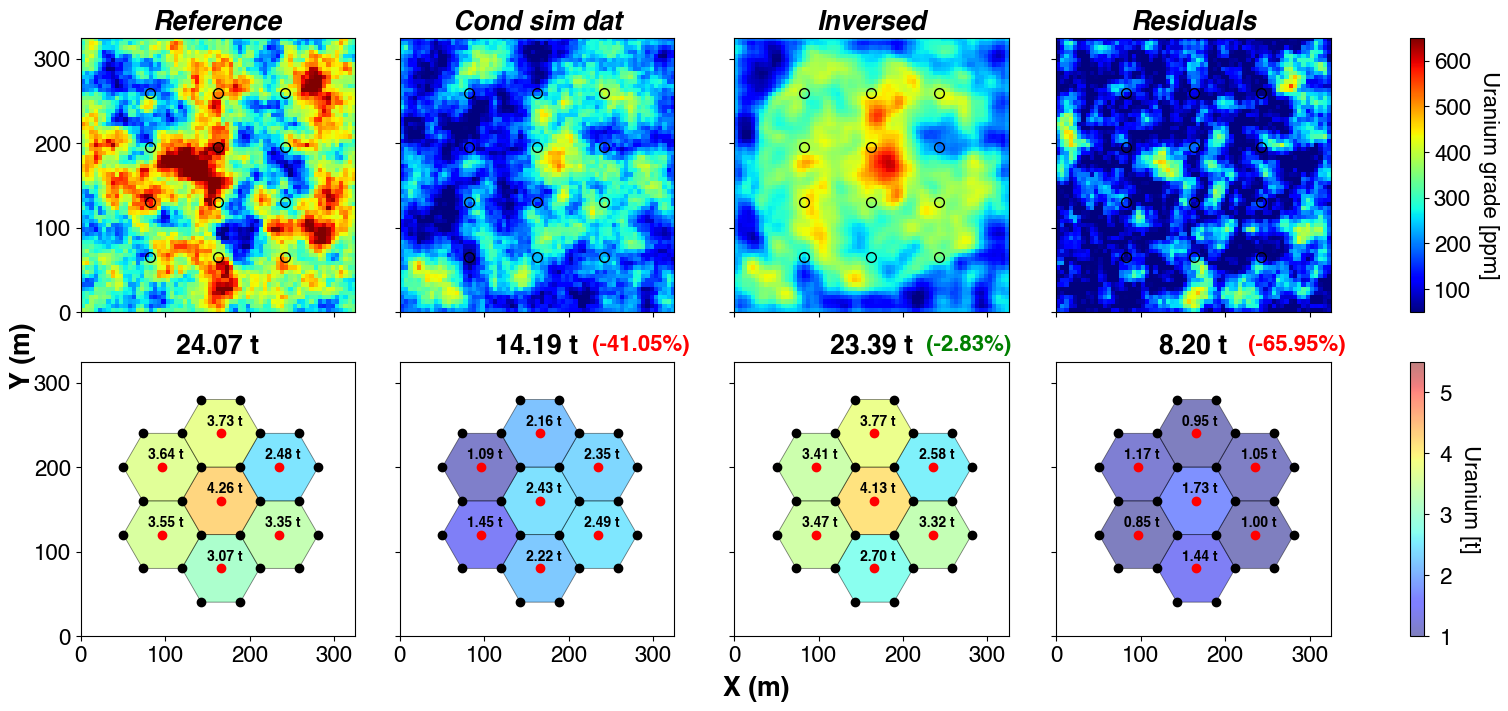

In [55]:
plot_inv_res_grade_and_reserves(
    ref_grade=reference_grade,
    prior_grade=estimate_grade_simu,
    inversed_grade=grade_mol_per_kg_to_ppm(
        model_adjusted_adjoint.tr_model.grade[:, :, 0]
    ),
    case_name="adjoint",
)

In [56]:
if is_run_all or is_run_adjoint:
    plotter = AnimatedPlotter(
        fig_params={"figsize": (10.0, 8.0)}, subfigs_params={"nrows": 2, "ncols": 2}
    )

    # 1 frame per solver iteration
    nb_frames: int = inverse_model_adjoint.nb_f_calls

    aligned_adjoint_gradients = get_gridded_archived_gradients(
        adjusted_param_adjoint, is_adjoint=True
    )

    # 1) Gradient evolution
    plotter.animated_multi_imshow(
        ax_names=["ax1-1"],
        data={
            "Gradient": aligned_adjoint_gradients,
        },
        # cbar_title="Adjoit head",
        nb_frames=nb_frames,
        imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "aspect": "equal"},
        xlabel="X [m]",
        ylabel="Y [m]",
        is_symetric_cbar=True,
    )
    plotter.get_axis("ax1-1").set_title("Gradient", fontweight="bold")

    if language == Lg.ENGLISH:
        labels = [
            "Uranium grade",
            "Cost function",
        ]
    else:
        labels = [
            "Teneurs en uranium",
            "Fonction de perte",
        ]

    # 2) Parameter evolution
    plotter.animated_multi_imshow(
        ax_names=["ax1-2"],
        data={
            labels[0]: grade_mol_per_kg_to_ppm(
                np.transpose(
                    np.array(adjusted_param_adjoint.archived_values), axes=[1, 2, 0]
                )
            ),
        },
        nb_frames=nb_frames,
        imshow_kwargs={
            "extent": [0.0, nx * dx, 0.0, ny * dy],
            "aspect": "equal",
            # "norm": LogNorm(vmin=1e-5, vmax=1e-3),
            "cmap": plt.get_cmap("jet"),
            "extent": [0.0, nx * dx, 0.0, ny * dy],
            "vmin": 50,
            "vmax": 650,
        },
        xlabel="X [m]",
        ylabel="Y [m]",
    )

    plotter.get_axis("ax1-2").set_title(f"{labels[0]} [ppm]", fontweight="bold")

    # 3) Objective function
    vals = inverse_model_adjoint.list_f_res
    obj_fun_vals = np.full((len(vals), nb_frames), fill_value=np.nan)
    for i in range(len(vals)):
        obj_fun_vals[: i + 1, i] = vals[: i + 1]

    plotter.animated_multi_plot(
        ax_name="ax2-1",
        data={
            labels[1]: {"y": obj_fun_vals, "kwargs": {"c": "r", "linestyle": "--"}},
        },
        nb_frames=nb_frames,
        title=labels[1],
        xlabel="Iteration #",
    )
    plotter.ax_dict["ax2-1"].set_yscale("log")

    # 4) Observation vs predicted values
    plotter.animated_multi_plot(
        ax_name="ax2-1",
        data={
            labels[1]: {"y": obj_fun_vals, "kwargs": {"c": "r", "linestyle": "--"}},
        },
        nb_frames=nb_frames,
        title=labels[1],
        xlabel="Iteration #",
    )
    plotter.ax_dict["ax2-1"].set_yscale("log")

    # 4) Observation vs predicted values
    pyrtid.plot.plot_observed_vs_simulated(
        plotter.ax_dict["ax2-2"],
        obs_vector=conc_molpl_to_mgpl(
            dminv.get_observables_values_as_1d_vector(observables)
        ),
        pred_vector_initial=conc_molpl_to_mgpl(
            dminv.get_predictions_matching_observations(model_estimate, observables)
        ),
        units="mg/l",
    )
    plotter.animated_multi_plot(
        ax_name="ax2-2",
        data={
            "current": {
                "x": conc_molpl_to_mgpl(
                    dminv.get_observables_values_as_1d_vector(observables)
                ),
                "y": conc_molpl_to_mgpl(
                    np.array(executor_adjoint.inv_model.list_d_pred).T
                ),
                "kwargs": {"c": "b", "linestyle": "none", "marker": ".", "zorder": 2},
            },
        },
        nb_frames=nb_frames,
    )
    # Add a legend
    plotter.get_axis("ax2-2").legend(loc="upper left")

    plotter.close()
    plotter.animate(nb_frames=nb_frames)
    # Save the animation locally on the computer
    fname_html = fig_save_path.joinpath("inversion_animation_adjoint.html")
    writer = HTMLWriter(fps=2, embed_frames=True)
    writer.frame_format = "svg"  # Ensure svg format
    plotter.animation.save(str(fname_html), writer=writer)

    # Extract the svg from the html file (for animation in Latex)
    extract_frames_from_embedded_html_animation(fname_html)

    extract_frames_from_embedded_html_animation(fname_html)

    # Display the animation
    HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


## Inversion with PCGA

In [57]:
is_run_pcga = True

- Check what kernel to use for PyPCGA (not great though...) must refactor the lib.

In [58]:
def matern_kernel(r: NDArrayFloat, l: float = 1, v: float = 1) -> NDArrayFloat:
    """
    Computes Matérn correlation function for given distances.

    Parameters:
    -----------
    r : array
        Distances between locations.
    l : float
        Range parameter (ϕ). Must be greater than 0.
    v : float
        Smoothness parameter (nu). Must be greater than 0.
    Returns:
    --------
    Array giving Matern correlation for given distances.
    """
    r = np.abs(r)
    r[r == 0] = 1e-8
    return (
        2 ** (1 - v)
        / scipy.special.gamma(v)
        * (np.sqrt(2 * v) * r / l) ** v
        * scipy.special.kv(v, np.sqrt(2 * v) * r / l)
    )


def matern_kernel_wrapper(r: NDArrayFloat) -> NDArrayFloat:
    spatial_dim = 2
    _nu = 2 * alpha - spatial_dim / 2
    return (estimated_std**2) * matern_kernel(r * len_scale, len_scale, _nu)

In [59]:
from pyrtid.inverse.regularization import (
    FFTCovarianceMatrix,
    SparseInvCovarianceMatrix,
    get_prior_eigen_factorization,
    cov_mat_to_ud_mat,
    CovarianceMatrix,
)

cov_mat_fft = FFTCovarianceMatrix(
    matern_kernel_wrapper, (dx, dy), (nx, ny), (1 / kappa, 1 / kappa), 0.0
)
cov_mat_spde = SparseInvCovarianceMatrix(Q_init)

eigval_fft, eigvec_fft = get_prior_eigen_factorization(
    cov_mat_fft,
    100,
    random_state=rng,
)
eigval_spde, eigvec_spde = get_prior_eigen_factorization(
    cov_mat_spde, 100, random_state=rng
)

INFO:root:Tree building time = 0.0010645389556884766
INFO:root:Nearest neighbor computation time = 0.05032038688659668
INFO:root:Elapsed time = 25.0429
INFO:root:Eigendecomposition of Prior Covariance
INFO:root:- time for eigendecomposition with k = 100 is 1 sec
INFO:root:- 1st eigv : 1.06073e+06, 100-th eigv : 101092, ratio: 0.0953047
INFO:root:Eigendecomposition of Prior Covariance
INFO:root:- time for eigendecomposition with k = 100 is 2 sec
INFO:root:- 1st eigv : 1.95747e+06, 100-th eigv : 60190.4, ratio: 0.0307491


- Plot the eigen values and the associated explained variance in order to choose the number of principal component required for the inversion.

INFO:root:n pc (50% variance) = 46
INFO:root:n pc (80% variance) = 101


([<matplotlib.lines.Line2D at 0x7fe054f90050>], ['fft'])

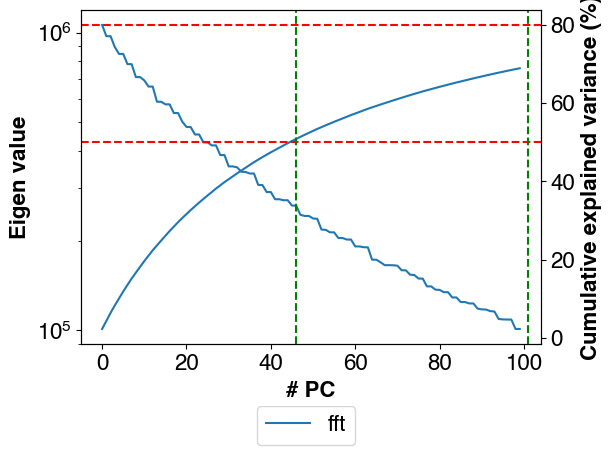

In [60]:
plotter = NestedGridPlotter(fig_params={"constrained_layout": True, "figsize": (6, 4)})

# fig, ax = plt.subplots(1, 1)
ax = plotter.axes[0]

variance_threshold_1 = 0.5  # we want to keep 90% of the explained variance
variance_threshold_2 = 0.8  # we want to keep 90% of the explained variance
# eigen values
ax.plot(eigval_fft, label="fft")
# ax.plot(eigval_spde, label="spde")
ax.set_yscale("log")
ax.set_xlabel("# PC", fontweight="bold")
ax.set_ylabel("Eigen value", fontweight="bold")

n_pc_threshold_1 = (
    np.searchsorted(
        np.cumsum(get_explained_var(eigval_fft, cov_mat_fft)), variance_threshold_1
    )
    + 1
)
n_pc_threshold_2 = (
    np.searchsorted(
        np.cumsum(get_explained_var(eigval_fft, cov_mat_fft)), variance_threshold_2
    )
    + 1
)
logging.info(f"n pc (50% variance) = {n_pc_threshold_1}")
logging.info(f"n pc (80% variance) = {n_pc_threshold_2}")


# Variance
ax2 = plt.twinx(ax)
ax2.plot(np.cumsum(get_explained_var(eigval_fft, cov_mat_fft)) * 100.0, label="fft")
# ax2.plot(np.cumsum(get_explained_var(eigval_spde, cov_mat_fft)) * 100.0, label="spde")

ax2.axhline(variance_threshold_1 * 100.0, linestyle="--", color="r")
ax2.axhline(variance_threshold_2 * 100.0, linestyle="--", color="r")
ax2.axvline(n_pc_threshold_1, linestyle="--", color="g")
ax2.axvline(n_pc_threshold_2, linestyle="--", color="g")
ax2.set_ylabel("Cumulative explained variance (%)", fontweight="bold")

plotter.add_fig_legend(ncol=2)

Text(0.02, 0.5, 'Y (m)')

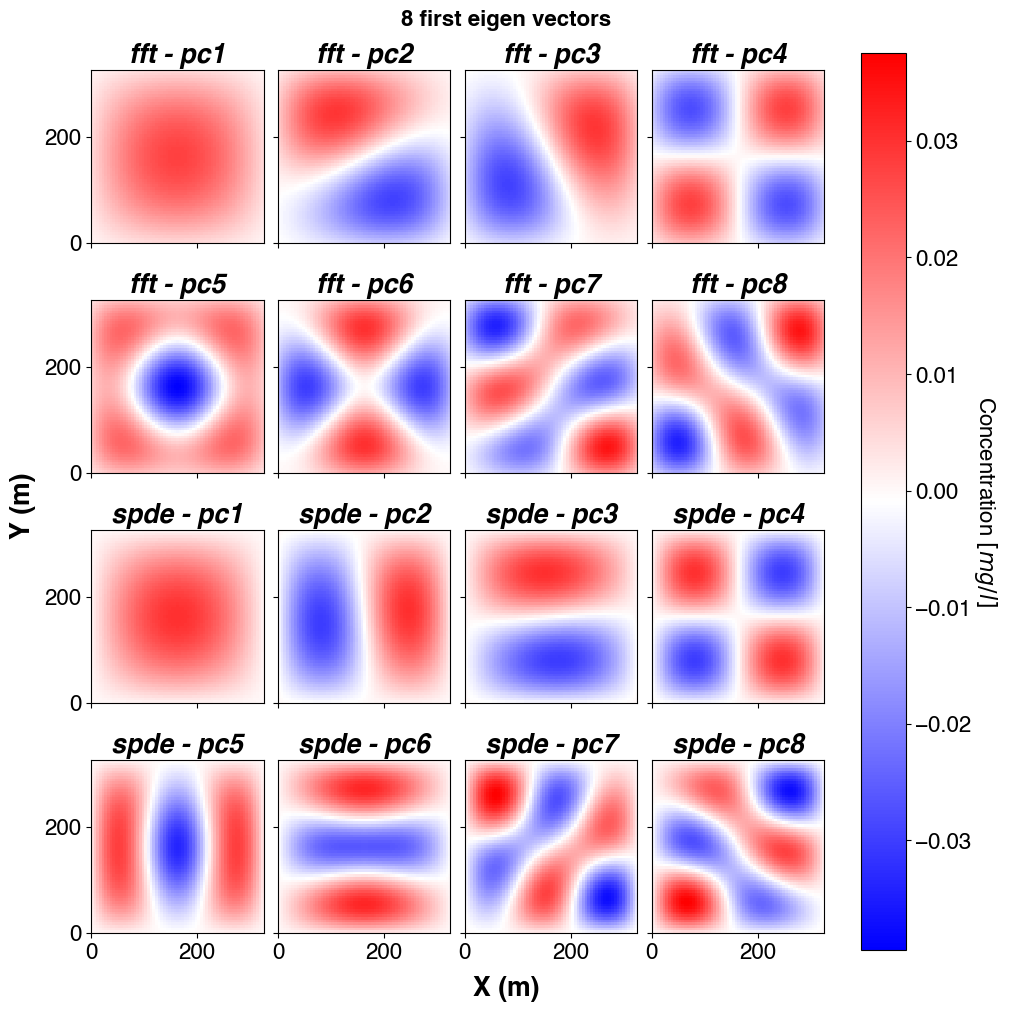

In [61]:
# Plot a concentration animation Here !
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 10)},
    subfigs_params={"nrows": 1},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[
                ["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
                ["ax2-1", "ax2-2", "ax2-3", "ax2-4"],
                ["ax3-1", "ax3-2", "ax3-3", "ax3-4"],
                ["ax4-1", "ax4-2", "ax4-3", "ax4-4"],
            ],
            sharey=True,
            sharex=True,
        ),
    },
)


# 1) FFT et SPDE
multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        **{f"fft - pc{i + 1}": eigvec_fft[:, i].reshape(nx, ny) for i in range(8)},
        **{f"spde - pc{i + 1}": eigvec_spde[:, i].reshape(nx, ny) for i in range(8)},
    },
    cbar_title="Concentration $[mg/l]$",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy], "aspect": "equal"},
)

plotter.subfigs["fig0"].suptitle("8 first eigen vectors", fontweight="bold", size=16)
plotter.subfigs["fig0"].supxlabel("X [m]", fontweight="bold")
plotter.subfigs["fig0"].supylabel("Y [m]", fontweight="bold")

In [62]:
adjusted_param_pcga = dminv.AdjustableParameter(
    name=dminv.ParameterName.INITIAL_GRADE,
    lbound=0.0,
    ubound=grade_ppm_to_mol_per_kg(700.0)[0],
    preconditioner=grade_mol_per_kg_to_ppm,
    backconditioner=grade_ppm_to_mol_per_kg,
    eps=1e-6,
)

from typing import Dict  # Just for linting

observables = []
for i, (ix, iy) in enumerate(prod_grid_indices):
    observables.append(
        dminv.Observable(
            state_variable=dminv.StateVariable.CONCENTRATION,
            node_indices=indices_to_node_number(ix, nx, iy),
            times=obs_times_in_s,
            values=obs_values[i],
            uncertainties=noise_std,
        )
    )

xmin: NDArrayFloat = np.array([0.5 * dx, 0.5 * dy])
xmax: NDArrayFloat = np.array([(nx - 0.5) * dx, (ny - 0.5) * dy])

solver_kwargs = {
    "R": (noise_std) ** 2,
    "n_pc": 50,
    "maxiter": 5,
    "restol": threshold_loss,
    "matvec": "FFT",
    "xmin": xmin,
    "xmax": xmax,
    "N": np.array((nx, ny), dtype=np.int8),
    "prior_std": estimated_std,  # 150 ppm
    "prior_cov_scale": np.array([1 / kappa, 1 / kappa]),
    "kernel": matern_kernel_wrapper,
    "post_cov": "diag",
    "precond": True,
    "LM": False,
    "parallel": True,
    "linesearch": False,
    "forward_model_verbose": False,
    "verbose": True,
    "iter_save": True,
}

solver_config_pcga = dminv.PCGASolverConfig(
    is_parallel=True,
    max_workers=max_workers,  # max four processes in parrallel.
    solver_kwargs=solver_kwargs,
    hm_end_time=20,
)

model_adjusted_pcga = copy.deepcopy(model_estimate)
model_adjusted_pcga.time_params.duration = duration_in_seconds_inv

inverse_model_reg2b_pcga = dminv.InverseModel(adjusted_param_pcga, observables)

executor_pcga = dminv.PCGAInversionExecutor(
    model_adjusted_pcga, inverse_model_reg2b_pcga, solver_config_pcga
)

# Compute a first objective function
executor_pcga.scaled_loss_function(
    get_param_values(adjusted_param_pcga, is_preconditioned=True),
    is_save_state=True,
)

/home/acollet/workspace/pyrtid/pyrtid/inverse/params.py:261: UserWarning: The given preconditioner 1st derivative check by finite difference failed ! The given function might no match the preconditioner or is not defined on the given bounds: lbound = 0.0, ubound = 0.02132340153452685. Note that it can also append if bounds are very huge number, e.g., 1e20.
  warnings.warn(
INFO:root:- Running forward model # 1


##### PCGA Inversion #####
##### 1. Initialize forward and inversion parameters
------------ Inversion Parameters -------------------------
   Number of unknowns                               : 4225
   Number of observations                           : 7
   Number of principal components (n_pc)            : 50
   Prior model                                      : def matern_kernel_wrapper(r: NDArrayFloat) -> NDArrayFloat:
    spatial_dim = 2
    _nu = 2 * alpha - spatial_dim / 2
    return (estimated_std**2) * matern_kernel(r * len_scale, len_scale, _nu)

   Prior variance                                   : 1.119828e+04
   Prior scale (correlation) parameter              : [20. 20.]
   Posterior cov computation                        : diag
   Posterior variance computation                   : Direct
   Number of CPU cores (n_core)                     : 4
   Maximum GN iterations                            : 5
   machine precision (delta = sqrt(precision))      : 1.000000e-08
   Tol f

KeyboardInterrupt: 

In [ ]:
# Run inversion
(
    _s_inversed_best_pcga,
    simul_obs_best_pcga,
    post_diagv_best_pcga,
    iter_best_pcga,
) = executor_pcga.run()

- Need to run PCGA once again

In [ ]:
losses_pcga = []

for file in sorted(Path.cwd().glob("simulobs*")):
    print(file)
    _pred_vals = np.loadtxt(file)
    ls = (
        dminv.ls_loss_function(
            _pred_vals,
            dminv.get_observables_values_as_1d_vector(
                executor_pcga.inv_model.observables
            ),
            dminv.get_observables_uncertainties_as_1d_vector(
                executor_pcga.inv_model.observables
            ),
        )
        * executor_pcga.inv_model.scaling_factor
    )
    losses_pcga.append(ls)

losses_pcga = [loss / losses_pcga[0] for loss in losses_pcga]
pcga_loss_index = 0

for pcga_loss_index, loss in enumerate(losses_pcga):
    if loss < threshold_loss:
        break

print(pcga_loss_index)

plt.plot(losses_pcga)
plt.yscale("log")

In [ ]:
model_adjusted_pcga.tr_model.set_initial_grade(
    grade_ppm_to_mol_per_kg(_s_inversed_best_pcga.reshape(nx, ny, order="F"))
)
model_adjusted_pcga.time_params.duration = duration_in_seconds
solver_pcga_post_inv = dmfwd.ForwardSolver(model_adjusted_pcga)
solver_pcga_post_inv.solve()

In [ ]:
plot_inv_res_conc_at_producers(
    ref_model=model_reference,
    prior_model=model_estimate,
    inversed_model=model_adjusted_pcga,
    case_name="pcga",
)

In [ ]:
plotter = plot_inv_res_conc_at_producers(
    ref_model=model_reference,
    prior_model=model_estimate,
    inversed_model=model_adjusted_adjoint_full,
    case_name="ASM",
)

# Indicate the order in which to plot
obs_plot_locations = ["ax2-3", "ax1-2", "ax3-2", "ax2-2", "ax1-1", "ax3-1", "ax2-1"]

# Static plot
for count, ((ix, iy), ax_name) in enumerate(zip(prod_grid_indices, obs_plot_locations)):
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    if language == Lg.ENGLISH:
        obs_well_name = f"obs. well @ x={x:.1f}m, y={y:.1f}m"
    else:
        obs_well_name = f"producteur @ x={x:.1f}m, y={y:.1f}m"

    ax = plotter.ax_dict[ax_name]
    data = {
        "Post-inversion (PCGA)": {
            "x": time_all[: model_adjusted_pcga.time_params.nt + 1],
            "y": conc_molpl_to_mgpl(model_adjusted_pcga.tr_model.conc[ix, iy, :]),
            "kwargs": {"c": "k", "linestyle": "-."},
        },
    }

    for k, v in data.items():
        ax.plot(v["x"], v["y"], **v["kwargs"], label=k)


plotter.add_fig_legend(ncol=3)
if language == Lg.FRENCH:
    plotter.fig.supxlabel("Temps [j]", fontweight="bold")
    plotter.fig.supylabel("U [mg/l]", fontweight="bold")
else:
    plotter.fig.supxlabel("Time [d]", fontweight="bold")
    plotter.fig.supylabel("U [mg/l]", fontweight="bold")

fname = f"U_at_producers_post_inv_asm_pcga"
for format in ["png", "pdf"]:
    plotter.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

In [ ]:
plot_inv_res_grade_and_reserves(
    ref_grade=reference_grade,
    prior_grade=estimate_grade_simu,
    inversed_grade=_s_inversed_best_pcga.reshape(
        nx, ny, order="F"
    ),  # grade_mol_per_kg_to_ppm(model_adjusted_pcga.tr_model.grade[:, :, 0]),
    case_name="pcga",
)

- Plot uncertainties

In [ ]:
plt.imshow(
    np.sqrt(post_diagv_best_pcga).reshape(nx, ny, order="F").T,
    origin="lower",
    cmap="jet",
)
plt.colorbar()

- Plot the objective function deacrease

In [ ]:
losses_pcga

# Inversion with ESMDA


In [ ]:
is_run_esmda = True

- Generate a 100 fields for the inversion

In [ ]:
if is_run_all or is_run_esmda:
    tmp = []
    n_fields = 100
    for i in range(n_fields):
        _field = np.abs(
            spde.simu_c(
                cholQ_init,
                Q_init_c,
                cholQ_init_c,
                dat_val_wrong - estimated_mean,
                dat_nn,
                dat_var_init,
                random_state=None,
            )
            .reshape(ny, nx)
            .T
            + estimated_mean
        )

        tmp.append(np.where(_field < 0.0, 0.0, _field).ravel("F"))
    initial_esmda_values_ppm = np.array(tmp)
    initial_esmda_values_molpl = grade_ppm_to_mol_per_kg(initial_esmda_values_ppm)

- Plot the std of the ensemble

In [ ]:
prior_var = get_ensemble_variance(initial_esmda_values_ppm)

plt.imshow(np.sqrt(prior_var).reshape(nx, ny, order="F").T, cmap="jet", origin="lower")
plt.colorbar()

- Create correlation matrices to avoid spourious correlations

In [ ]:
# Vectors of x and y coordinates (case of a regular grid)
x_vect_coords = np.linspace(0, (nx - 1) * dx, nx)
y_vect_coords = np.linspace(0, (ny - 1) * dy, ny)

# Build grid coordinates from it -> 2D array with dimensions (nx * ny, 2)
coordinates = np.array(np.meshgrid(x_vect_coords, y_vect_coords)).reshape(2, -1).T

# 20 cells expected
print(coordinates.shape)

# mesh indices
mesh_indices = np.arange(nx * ny).reshape(ny, nx)

- The distance and weight matrices can be directly computed from these two vectors

In [ ]:
obs_size_per_well = obs_time_idx[obs_time_idx].size
obs_size_per_well

In [ ]:
# one coordinates set per obs value
obs_val_coords = np.concatenate(
    [
        [prod_grid_coordinates[i]] * obs_size_per_well
        for i in range(len(prod_grid_coordinates))
    ],
    axis=0,
)
obs_val_coords.shape

In [ ]:
coordinates.shape

In [ ]:
md_space_correlation_matrix = lil_array((coordinates.shape[0], obs_val_coords.shape[0]))

# distance matrix computation
for i, (ox, oy) in enumerate(prod_grid_coordinates):
    md_space_correlation_matrix[
        :, i * obs_size_per_well : (i + 1) * obs_size_per_well
    ] = distances_to_weights_beta_cumulative(
        distance_matrix(coordinates, [[ox, oy]]).ravel()[:, np.newaxis],
        beta=3,
        scaling_factor=150,
    )


def get_sparcity(mat: csr_array) -> float:
    return mat.count_nonzero() / np.prod(mat.shape)


print(f"md_space_correlation_matrix.shape = {md_space_correlation_matrix.shape}")
print(f"matrix sparcity = {get_sparcity(md_space_correlation_matrix.tocsr())}")


print(f"md_space_correlation_matrix.shape = {md_space_correlation_matrix.shape}")

# Plot the correlation matrix
plt.imshow(md_space_correlation_matrix.toarray(), aspect="auto")
plt.xlabel("Obs")
plt.ylabel("Params")
plt.colorbar(label="weights")

In [ ]:
plt.imshow(distance_matrix(obs_val_coords, obs_val_coords))
plt.colorbar()

In [ ]:
dd_space_correlation_matrix = csc_array(
    distances_to_weights_beta_cumulative(
        distance_matrix(obs_val_coords, obs_val_coords),
        beta=3,
        scaling_factor=150,
    )
)

print(f"dd_space_correlation_matrix.shape = {dd_space_correlation_matrix.shape}")
print(f"matrix sparcity = {get_sparcity(dd_space_correlation_matrix.tocsr())}")


print(f"dd_space_correlation_matrix.shape = {dd_space_correlation_matrix.shape}")

# Plot the correlation matrix
plt.imshow(dd_space_correlation_matrix.toarray(), aspect="auto")
plt.xlabel("Obs")
plt.ylabel("Obs")
plt.colorbar(label="weights")

In [ ]:
dd_space_correlation_matrix.shape

In [ ]:
plotter_wf = NestedGridPlotter(fig_params={"figsize": (5, 5)})
ax = plotter_wf.ax_dict["ax1-1"]

for i, j in inj_grid_coordinates:
    ax.plot(i, j, "ko")

for i, j in prod_grid_coordinates:
    ax.plot(i, j, "ro")

patches = []
for polygon in polygons:
    # Add the polygon to the collection of patches
    xy = np.array(polygon)
    patches.append(Polygon(xy, closed=True, facecolor=None))
    # Plot the number of the polygon
p = PatchCollection(patches, alpha=0.0)
# p.set_facecolors("white")
p.set_edgecolors("darkgrey")
p.set_linewidth(0.8)
p.set_linestyle("-")
ax.add_collection(p)

for i, prod_coords in enumerate(prod_grid_coordinates):
    ax.text(prod_coords[0] - 2, prod_coords[1] + 8, i)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, nx * dx)
ax.set_ylim(0, ny * dy)
ax.set_xlabel("X [m]", fontweight="bold")
ax.set_ylabel("Y [m]", fontweight="bold")

# Add the weights
well_id = 0
fd = (
    md_space_correlation_matrix[:, int(well_id + 0.5) * obs_size_per_well]
    .toarray()
    .reshape(nx, ny, order="F")
)
ix, iy = prod_grid_indices[well_id]
ax.imshow(fd.T, origin="lower", extent=[0.0, nx * dx, 0.0, ny * dy])

In [ ]:
adjusted_param_esmda = dminv.AdjustableParameter(
    name=dminv.ParameterName.INITIAL_GRADE,
    lbound=0.0,
    ubound=float(grade_ppm_to_mol_per_kg(1500.0)),
)

is_restricted_step = True

observables = []
for i, (ix, iy) in enumerate(prod_grid_indices):
    observables.append(
        dminv.Observable(
            state_variable=dminv.StateVariable.CONCENTRATION,
            node_indices=indices_to_node_number(ix, nx, iy),
            times=obs_times_in_s,
            values=obs_values[i],
            uncertainties=noise_std,
        )
    )


model_adjusted_esmda = copy.deepcopy(model_estimate)
model_adjusted_esmda.time_params.duration = duration_in_seconds_inv

inverse_model_esmda = dminv.InverseModel(adjusted_param_esmda, observables)

if is_restricted_step:
    solver_config_esmda = dminv.ESMDARSSolverConfig(
        is_parallel=True,
        max_workers=max_workers,  # max four processes in parrallel.
        save_ensembles_history=True,  # this must be ON for the plots,
        sd_correlation_matrix=md_space_correlation_matrix.tocsc(),
        dd_correlation_matrix=dd_space_correlation_matrix,
        cov_ss_inflation_factor=1.2
        # batch_size=1000
    )
    executor_esmda = dminv.ESMDARSInversionExecutor(
        model_adjusted_esmda,
        inverse_model_esmda,
        solver_config_esmda,
        s_init=initial_esmda_values_molpl,
    )
else:
    solver_config_esmda = dminv.ESMDASolverConfig(
        is_parallel=True,
        max_workers=max_workers,  # max four processes in parrallel.
        save_ensembles_history=True,  # this must be ON for the plots,
        n_assimilations=3,
        sd_correlation_matrix=md_space_correlation_matrix.tocsc(),
        dd_correlation_matrix=dd_space_correlation_matrix,
        cov_ss_inflation_factors=[2.0, 1.0, 1.0]  # , 1.5, 1.0, 1.0],
        # batch_size=1000
    )
    executor_esmda = dminv.ESMDAInversionExecutor(
        model_adjusted_esmda,
        inverse_model_esmda,
        solver_config_esmda,
        s_init=initial_esmda_values_molpl,
    )


# Compute a first objective function
executor_esmda.scaled_loss_function(
    get_param_values(adjusted_param_esmda, is_preconditioned=False),
    is_save_state=False,
)

In [ ]:
executor_esmda.run()

# Rebuilt the esmda full history of curves.

In [ ]:
losses_esmda = []
for d_pred in executor_esmda.solver.d_history:
    d_average = np.average(d_pred, axis=0)
    ls = (
        dminv.ls_loss_function(
            d_average,
            dminv.get_observables_values_as_1d_vector(
                executor_esmda.inv_model.observables
            ),
            dminv.get_observables_uncertainties_as_1d_vector(
                executor_esmda.inv_model.observables
            ),
        )
        * executor_esmda.inv_model.scaling_factor
    )
    losses_esmda.append(ls)

losses_esmda = [loss / losses_esmda[0] for loss in losses_esmda]
esmda_loss_index = 0

for esmda_loss_index, loss in enumerate(losses_esmda):
    if loss < threshold_loss:
        break

print(esmda_loss_index)

plt.plot(losses_esmda)
plt.yscale("log")

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from typing import Iterator

s_init = executor_esmda.s_history[0]
s_final = executor_esmda.s_history[esmda_loss_index]


# Function to run the model with a given uraninite field
def _run_forward_model(s, n_run) -> NDArrayFloat:
    logging.info(f"Running model #{n_run}")
    _model = copy.deepcopy(model_estimate)
    _model.update_nt(nt)
    _model.tr_model.set_initial_grade(s.reshape(nx, ny, order="F"))
    _solver = dmfwd.ForwardSolver(_model)
    _solver.solve()

    out = np.zeros((len(prod_grid_coordinates), nt + 1))

    for i, (ix, iy) in enumerate(prod_grid_indices):
        # node_id = indices_to_node_number(ix, nx=nx, iy=iy)
        out[i] = _model.tr_model.conc[ix, iy, :]

    logging.info(f"- Running model #{n_run} - Over")

    return out


def _map_run_froward_model(s) -> NDArrayFloat:
    _d_pred = np.zeros((len(prod_grid_coordinates), n_fields, nt + 1))
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results: Iterator[NDArrayFloat] = executor.map(
            _run_forward_model,
            s,
            range(n_fields),
        )
        for j, res in enumerate(results):
            _d_pred[:, j, :] = res
    return _d_pred


d_pred_init = _map_run_froward_model(executor_esmda.s_history[0])
d_pred_final = _map_run_froward_model(executor_esmda.s_history[-1])

In [ ]:
d_pred_init.shape

In [ ]:
d_pred_final.shape

In [ ]:
from typing import List


def plot_inv_res_conc_at_producers_ensemble(
    *,
    ref_model: dmfwd.ForwardModel,
    prior_model: dmfwd.ForwardModel,
    d_pred_init: NDArrayFloat,
    d_pred_final: NDArrayFloat,
    case_name: str,
) -> NestedGridPlotter:
    """

    Parameters
    ----------
    ref_model : _type_
        _description_
    prior_model : _type_
        _description_
    inversed_model : _type_
        _description_

    Returns
    -------
    NestedGridPlotter
        _description_
    """
    # Indicate the order in which to plot
    obs_plot_locations = ["ax2-3", "ax1-2", "ax3-2", "ax2-2", "ax1-1", "ax3-1", "ax2-1"]

    plotter = NestedGridPlotter(
        fig_params={"constrained_layout": True, "figsize": (12, 8)},
        subfigs_params={
            "ncols": 3  # np.unique(np.array(prod_grid_locations)[:, 0].round()).size,
        },
        subplots_mosaic_params={
            "left_col": dict(
                mosaic=[["ghost1"], ["ax1-1"], ["ax1-2"], ["ghost2"]],
                gridspec_kw=dict(
                    height_ratios=[1.0, 1.2, 1.2, 1.0],
                ),
                sharey=True,
                sharex=True,
            ),
            "centered_col": dict(
                mosaic=[["ax2-1"], ["ax2-2"], ["ax2-3"]], sharey=True, sharex=True
            ),
            "right_col": dict(
                mosaic=[["ghost3"], ["ax3-1"], ["ax3-2"], ["ghost4"]],
                gridspec_kw=dict(
                    height_ratios=[1.0, 1.2, 1.2, 1.0],
                ),
                sharey=True,
                sharex=True,
            ),
        },
    )

    # hide axes and borders
    plotter.ax_dict["ghost1"].axis("off")
    plotter.ax_dict["ghost2"].axis("off")
    plotter.ax_dict["ghost3"].axis("off")
    plotter.ax_dict["ghost4"].axis("off")

    # Static plot
    for count, ((ix, iy), ax_name) in enumerate(
        zip(prod_grid_indices, obs_plot_locations)
    ):
        x = (ix + 0.5) * dx
        y = (iy + 0.5) * dy
        if language == Lg.ENGLISH:
            obs_well_name = f"obs. well @ x={x:.1f}m, y={y:.1f}m"
        else:
            obs_well_name = f"producteur @ x={x:.1f}m, y={y:.1f}m"

        ax = plotter.ax_dict[ax_name]
        ax.set_title(obs_well_name, fontweight="bold", fontsize=12, fontstyle="italic")

        if language == Lg.ENGLISH:
            labels = ["Reference noisy", "Reference", "A priori"]
        else:
            labels = ["Réference bruitée", "Réference", "A priori"]
        data = {
            labels[0]: {
                "x": time_all[obs_time_idx],
                "y": conc_molpl_to_mgpl(
                    ref_model.tr_model.conc[ix * 2, iy * 2, :] + obs_noise[count]
                )[obs_time_idx],
                "kwargs": {
                    "c": "b",
                    "marker": "o",
                    "linestyle": "None",
                    "alpha": 0.3,
                    "zorder": 10,
                },
            },
            labels[1]: {
                "x": time_all,
                "y": conc_molpl_to_mgpl(ref_model.tr_model.conc[ix * 2, iy * 2, :]),
                "kwargs": {"c": "b", "linestyle": "-", "alpha": 1, "zorder": 10},
            },
            labels[2]: {
                "x": time_all[: prior_model.time_params.nt + 1],
                "y": conc_molpl_to_mgpl(prior_model.tr_model.conc[ix, iy, :]),
                "kwargs": {"c": "r"},
            },
        }

        for k, v in data.items():
            ax.plot(v["x"], v["y"], **v["kwargs"], label=k)

        # plot the ensemble results (initial)
        # d_pred = d_history[0]
        # n_obs = int(d_pred.shape[1] / 7)
        # ax.plot(
        #     np.repeat(time_all[obs_time_idx].reshape(n_obs, -1), d_pred.shape[0], axis=1),
        #     conc_molpl_to_mgpl(d_pred[:, n_obs * count: n_obs * (count + 1)]).T, c="grey", alpha=0.2, label="initial ensemble", linestyle="-")

        # d_pred = d_history[-1]
        # n_obs = int(d_pred.shape[1] / 7)
        # ax.plot(
        #     np.repeat(time_all[obs_time_idx].reshape(n_obs, -1), d_pred.shape[0], axis=1),
        #     conc_molpl_to_mgpl(d_pred[:, n_obs * count: n_obs * (count + 1)]).T, c="blue", alpha=0.3, label="final ensemble", linestyle="-")

        if language == Lg.ENGLISH:
            labels = ["Initial ensemble", "Final ensemble", "Final ensemble average"]
        else:
            labels = ["Ensemble initial", "Ensemble final", "Moyenne ensemble final"]

        d_pred = d_pred_init[count]
        ax.plot(
            np.repeat(time_all.reshape(nt + 1, -1), d_pred.shape[0], axis=1),
            conc_molpl_to_mgpl(d_pred.T),
            c="grey",
            alpha=0.1,
            label=labels[0],
            linestyle="-",
        )

        d_pred = d_pred_final[count]
        ax.plot(
            np.repeat(time_all.reshape(nt + 1, -1), d_pred.shape[0], axis=1),
            conc_molpl_to_mgpl(d_pred.T),
            c="green",
            alpha=0.1,
            label=labels[1],
            linestyle="-",
        )

        d_pred = d_pred_final[count]
        ax.plot(
            time_all,
            conc_molpl_to_mgpl(np.mean(d_pred, axis=0)),
            c="k",
            alpha=1.0,
            zorder=5,
            label=labels[2],
            linestyle="--",
        )

        # d_pred = d_history[-1]
        # n_obs = int(d_pred.shape[1] / 7)
        # ax.plot(
        #     np.repeat(time_all[obs_time_idx].reshape(n_obs, -1), d_pred.shape[0], axis=1),
        #     conc_molpl_to_mgpl(d_pred[:, n_obs * count: n_obs * (count + 1)]).T, c="blue", alpha=0.3, label="final ensemble", linestyle="-")

    plotter.add_fig_legend(ncol=3)
    if language == Lg.FRENCH:
        plotter.fig.supxlabel("Temps [j]", fontweight="bold")
        plotter.fig.supylabel("U [mg/l]", fontweight="bold")
    else:
        plotter.fig.supxlabel("Time [d]", fontweight="bold")
        plotter.fig.supylabel("U [mg/l]", fontweight="bold")

    fname = f"U_at_producers_post_inv{case_name}"
    for format in ["png", "pdf"]:
        plotter.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)
    return plotter

In [ ]:
plot_inv_res_conc_at_producers_ensemble(
    ref_model=model_reference,
    prior_model=model_estimate,
    d_pred_init=d_pred_init,
    d_pred_final=d_pred_final,
    case_name="esmda",
)

In [ ]:
s_best_av_esmda = np.mean(executor_esmda.s_history[esmda_loss_index], axis=0).reshape(
    nx, ny, order="F"
)
s_best_av_esmda.shape

In [ ]:
plot_inv_res_grade_and_reserves(
    ref_grade=reference_grade,
    prior_grade=estimate_grade_simu,
    inversed_grade=grade_mol_per_kg_to_ppm(s_best_av_esmda),
    case_name="esmda",
)

- A posteriori error estimation

In [ ]:
post_var = get_ensemble_variance(executor_esmda.s_history[esmda_loss_index])
post_std_esmda_ppm = grade_mol_per_kg_to_ppm(np.sqrt(post_var)).reshape(
    nx, ny, order="F"
)

plt.imshow(post_std_esmda_ppm.T, cmap="jet", origin="lower")
plt.colorbar()

# Comparision

In [ ]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (9.0, 7.0)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1", "ax1-2"], ["ax2-1", "ax2-2"]], sharey=True, sharex=True
        )
    },
)

if language == Lg.ENGLISH:
    labels = [
        "PCGA - 1.96 \u03C3",
        "ESMDA - 1.96 \u03C3",
        "Residuals PCGA",
        "Residuals ESMDA",
    ]
    cbar_title = "Uranium grade [ppm]"
else:
    labels = [
        "PCGA - 1.96 \u03C3",
        "ESMDA - 1.96 \u03C3",
        "Résidus PCGA",
        "Résidus ESMDA",
    ]
    cbar_title = "Teneur en uranium [ppm]"

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        labels[0]: np.sqrt(post_diagv_best_pcga).reshape(nx, ny, order="F") * 1.96,
        labels[1]: post_std_esmda_ppm * 1.96,
        labels[2]: np.abs(
            reference_grade - _s_inversed_best_pcga.reshape(nx, ny, order="F")
        ),
        labels[3]: np.abs(reference_grade - grade_mol_per_kg_to_ppm(s_best_av_esmda)),
    },
    cbar_title=cbar_title,
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "vmin": 100,
        "vmax": 250,
        "aspect": "equal",
    },
    xlabel="X [m]",
    ylabel="Y [m]",
)

for ax in plotter.axes:
    # plot the sampling points here
    ax.plot(
        (dat_coords[0] + 0.5) * dx,
        (dat_coords[1] * dy),
        linestyle="None",
        marker="o",
        markersize=7,
        color="k",
        markerfacecolor="None",
    )

for letter, ax in zip(["a", "b", "c", "d"], plotter.axes):
    ax.text(
        0.0,
        1.0,
        letter,
        color="k",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
    )

fname = "uncertainties_and_residuals_pcga_esmda"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Plot inversion results

In [ ]:
def plot_inv_res_grade_and_reserves_comp(
    *,
    adjoint_grade: NDArrayFloat,
    pcga_grade: NDArrayFloat,
    esmda_grade: NDArrayFloat,
) -> NestedGridPlotter:
    plotter = NestedGridPlotter(
        fig_params={"constrained_layout": True, "figsize": (11.5, 10.5)},
        subplots_mosaic_params={
            "fig0": dict(
                mosaic=[
                    ["ax1-1", "ax1-2", "ax1-3"],
                    ["ax2-1", "ax2-2", "ax2-3"],
                    ["ax3-1", "ax3-2", "ax3-3"],
                ],
                sharey=True,
                sharex=True,
            )
        },
    )

    data = {
        "ASM": adjoint_grade,
        "PCGA": pcga_grade,
        "ESMDA": esmda_grade,
    }

    data_reserves = {}
    for k, v in data.items():
        data_reserves[k] = get_cell_reserves(v.T.ravel(), polygons, nx, ny, dx, dy, dz)

    if language == Lg.ENGLISH:
        cbar_title = "Uranium grade [ppm]"
    else:
        cbar_title = "Teneur en uranium [ppm]"

    # 1) Plot the grades
    cbar_up = multi_imshow(
        axes=plotter.axes[:3],
        fig=plotter.fig,
        data=data,
        cbar_title=cbar_title,
        imshow_kwargs={
            "cmap": plt.get_cmap("jet"),
            "extent": [0.0, nx * dx, 0.0, ny * dy],
            "vmin": 50,
            "vmax": 650,
        },
    )

    for ax in plotter.axes[:3]:
        # plot the sampling points here
        ax.plot(
            (dat_coords[0] + 0.5) * dx,
            (dat_coords[1] * dy),
            linestyle="None",
            marker="o",
            markersize=7,
            color="k",
            markerfacecolor="None",
        )

    # 2) Plot the reserves
    for _n, ax in enumerate(plotter.axes[3:6]):
        reserves = list(data_reserves.values())[_n]

        for i, j in inj_grid_coordinates:
            ax.plot(i, j, "ko")

        for i, j in prod_grid_coordinates:
            ax.plot(i, j, "ro")

        patches = []
        for i, cell_polygon in enumerate(polygons):
            # Add the polygon to the collection of patches
            xy = np.array(cell_polygon)
            patches.append(Polygon(xy, closed=True, facecolor=None))

            centroid = (xy.mean(axis=0)[0] - 10, xy.mean(axis=0)[1] + 10)

            ax.text(*centroid, f"{reserves[i]:.2f} t", fontsize=10, fontweight="bold")

            # Plot the number of the polygon
        p = PatchCollection(patches, alpha=0.5, cmap=plt.get_cmap("jet"))
        # p.set_facecolors("white")
        p.set_edgecolors("black")
        p.set_linewidth(0.6)
        p.set_linestyle("-")
        p.set_array(np.array(reserves, dtype=float))
        p.set_clim(1, 5.5)
        ax.add_collection(p)

        # Add the tonnages
        tmp = ax.set_title(f"{np.sum(reserves):.2f} t", fontweight="bold")

        # Absolute deviation
        ton_diff_abs = np.sum(reserves) - np.sum(reference_reserves)
        # Relative deviation
        ton_diff_rel = ton_diff_abs / np.sum(reference_reserves)

        pos = tmp.get_position()
        txt = ax.text(
            pos[0] + 0.2,
            pos[1] + 0.04,
            f"({ton_diff_rel * 100:+.2f}%)",
            fontweight="bold",
            transform=ax.transAxes,
            color="r" if np.abs(ton_diff_rel) > 0.1 else "g",
        )

    # Add a common colorbar
    cbar = plotter.fig.colorbar(
        p, ax=plotter.axes[3:6], orientation="vertical", fraction=0.1, format="%2.f"
    )
    cbar.ax.get_yaxis().labelpad = 20
    cbar.ax.set_ylabel("Uranium [t]", rotation=270)

    # 3) Plot the reserves deviation
    for _n, ax in enumerate(plotter.axes[6:]):
        reserves = list(data_reserves.values())[_n]
        _reserves_dev = [
            reserves[i] - reference_reserves[i] for i in range(len(reserves))
        ]

        for i, j in inj_grid_coordinates:
            ax.plot(i, j, "ko")

        for i, j in prod_grid_coordinates:
            ax.plot(i, j, "ro")

        patches = []
        for i, cell_polygon in enumerate(polygons):
            # Add the polygon to the collection of patches
            xy = np.array(cell_polygon)
            patches.append(Polygon(xy, closed=True, facecolor=None))

            centroid = (xy.mean(axis=0)[0] - 10, xy.mean(axis=0)[1] + 10)

            ax.text(
                *centroid, f"{_reserves_dev[i]:.2f} t", fontsize=10, fontweight="bold"
            )

            # Plot the number of the polygon
        p = PatchCollection(patches, alpha=0.5, cmap=plt.get_cmap("bwr"))
        # p.set_facecolors("white")
        p.set_edgecolors("black")
        p.set_linewidth(0.6)
        p.set_linestyle("-")
        p.set_array(np.array(_reserves_dev, dtype=float))
        p.set_clim(-1.0, 1.0)
        ax.add_collection(p)

        # Add the average cell deviation
        tmp = ax.set_title(
            f"\u00B1{np.mean(np.abs(_reserves_dev)):.2f} t", fontweight="bold"
        )

        # Relative deviation
        ton_diff_rel = np.mean(
            np.abs(
                [_reserves_dev[i] / reference_reserves[i] for i in range(len(reserves))]
            )
        )

        pos = tmp.get_position()
        txt = ax.text(
            pos[0] + 0.2,
            pos[1] + 0.04,
            f"(\u00B1{ton_diff_rel * 100:.2f}%)",
            fontweight="bold",
            transform=ax.transAxes,
            color="r" if np.abs(ton_diff_rel) > 0.1 else "g",
        )

    # Add a common colorbar
    cbar = plotter.fig.colorbar(
        p, ax=plotter.axes[6:], orientation="vertical", fraction=0.1, format="%2.f"
    )
    cbar.ax.get_yaxis().labelpad = 20
    if language == Lg.ENGLISH:
        cbar_title = "Uranium deviation [t]"
    else:
        cbar_title = "Différence [t]"
    cbar.ax.set_ylabel(cbar_title, rotation=270)

    for letter, ax in zip(["a", "b", "c", "d", "e", "f", "g", "h", "i"], plotter.axes):
        ax.text(
            0.0,
            1.0,
            letter,
            color="k",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="k", pad=5.0),
        )

    # Box dimensions
    for ax in plotter.ax_dict.values():
        ax.set_xlim(0, nx * dx)
        ax.set_ylim(0, ny * dy)
        ax.set_aspect("equal", adjustable="box")

    # plotter.fig.suptitle("Grades and tonnages", fontweight="bold", fontsize=22)
    plotter.fig.supxlabel("X [m]", fontweight="bold")
    plotter.fig.supylabel("Y [m]", fontweight="bold")

    fname = f"reserves_and_grades_per_cells_post_inv_comp"
    for format in ["png", "pdf"]:
        plotter.fig.savefig(
            str(fig_save_path.joinpath(f"{fname}.{format}")), format=format
        )
    return plotter

In [ ]:
plot_inv_res_grade_and_reserves_comp(
    adjoint_grade=grade_mol_per_kg_to_ppm(adjusted_param_adjoint.values),
    pcga_grade=_s_inversed_best_pcga.reshape(nx, ny, order="F"),
    esmda_grade=grade_mol_per_kg_to_ppm(s_best_av_esmda),
)

- Plot the comparision in terms of number of runs

In [ ]:
labels = ["Adjoint", "PCGA", "ESMDA"]
n_runs_adjoint = [executor_adjoint.inv_model.nb_g_calls, 0, 0]
# -1 for the forward call
n_runs_forward = [
    executor_adjoint.inv_model.nb_f_calls - 1,
    executor_pcga.inv_model.nb_f_calls - 1,
    initial_esmda_values_molpl.shape[0] * (esmda_loss_index + 1),
]
width = 0.35

fig, ax = plt.subplots(figsize=(4.3, 4))
fig.patch.set_facecolor("w")

if language == Lg.ENGLISH:
    bars = ax.bar(labels, n_runs_forward, width, label="Forward")
else:
    bars = ax.bar(labels, n_runs_forward, width, label="Direct")
ax.bar(labels, n_runs_adjoint, width, label="Adjoint", bottom=n_runs_forward)

if language == Lg.ENGLISH:
    ax.set_ylabel("Simulations nb.", weight="bold")
    ax.set_title("Number of runs", weight="bold", style="italic")
else:
    ax.set_ylabel("Nombre de simulations", weight="bold")
    ax.set_title("Nombre de simulations", weight="bold", style="italic")

ax.set_ylim(0, max(n_runs_forward) * 1.1)
ax.legend()

for bar, n_fwd, n_adj in zip(bars, n_runs_forward, n_runs_adjoint):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        (bar.get_height() / n_fwd) * (n_fwd + n_adj) + 1.5,
        round((n_fwd + n_adj), 1),
        horizontalalignment="center",
        color="k",
        weight="bold",
    )

fname = "n_runs_comp_french"
for format in ["png", "pdf"]:
    fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)